# Material Use and Embodied Carbon Intensity of New Construction Buildings in North America

**Note:** the core analysis only uses A1 to A3 data from New Construction projects.

## Import libraries

In [42]:
# Standard Libraries
import os
import warnings

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.cm as cm

# Plotly
import plotly.graph_objects as go
import plotly.subplots as sp
import plotly.express as px
import plotly.io as pio

# Statistical Analysis
from scipy.stats import gaussian_kde

# Dash for Web Applications
import dash
from dash import dcc, html, Input, Output, State, dash_table
import dash_bootstrap_components as dbc
from dash.dash_table.Format import Group
import base64

In [43]:
# Set the default font family for all plots
plt.rcParams['font.family'] = 'Calibri'  # Or any other font you prefer
# ['sans-serif'] was previously selected.

## Load and view datasets

### Load the data files into dataframes


In [44]:
wblca_results_full = pd.read_excel('./Input Data/full_lca_results_02-21-2025.xlsx')

# Remove rows where inv_mass or gwp is 0 or NaN
wblca_results_full = wblca_results_full[
    (~wblca_results_full['inv_mass'].isin([0, np.nan])) &
    (~wblca_results_full['gwp'].isin([0, np.nan]))
].reset_index(drop=True)

In [45]:
wblca_meta_data = pd.read_excel('./Input Data/buildings_metadata_02-21-2025.xlsx')

### View dataframes and a few features

In [46]:
wblca_results_full.head()

,project_index,omniclass_element,mat_group,mat_type,mat_csi_division,tally_revit_building_element,tally_material_group,oneclick_omniclass,oneclick_resource_type,service_life,...,inv_mass,inv_stored_carbon,gwp,ep,ap,sfp,odp,nred,mui_gfa,mui_cfa
0,1,Substructure,Steel,Steel sheet,05 - Metals,Substructure,Metal,NaN,NaN,45,...,14953.126660,0.0,34840.785118,6.145735,135.475328,1899.047086,4.441080e-04,4.142016e+05,0.598125,0.308312
1,1,Substructure,Coatings,Coatings - other,05 - Metals,Substructure,Metal Coating,NaN,NaN,50,...,29.247803,0.0,312.951490,0.040362,0.345124,6.346773,1.278129e-10,5.235357e+03,0.001170,0.000603
2,1,Substructure,Concrete,Ready mix NW 4000,03 - Concrete,Superstructure,Concrete,NaN,NaN,60,...,853083.412800,0.0,136036.682423,28.415153,460.278336,9695.231536,2.398774e-08,1.058441e+06,34.123337,17.589349
3,1,Substructure,Steel,Rebar and reinforcement,03 - Concrete,Superstructure,Metal,NaN,NaN,60,...,18030.252870,0.0,34437.782982,4.363321,144.963233,1718.283098,-1.552400e-04,4.164988e+05,0.721210,0.371758
4,1,Substructure,Concrete,Ready mix NW 4000,03 - Concrete,Superstructure,Concrete,NaN,NaN,60,...,254305.012100,0.0,40552.670056,8.470585,137.209429,2890.158144,7.150769e-09,3.155222e+05,10.172200,5.243402


In [47]:
wblca_results_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253356 entries, 0 to 253355
Data columns (total 21 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   project_index                 253356 non-null  int64  
 1   omniclass_element             253356 non-null  object 
 2   mat_group                     253356 non-null  object 
 3   mat_type                      253356 non-null  object 
 4   mat_csi_division              253356 non-null  object 
 5   tally_revit_building_element  245313 non-null  object 
 6   tally_material_group          245767 non-null  object 
 7   oneclick_omniclass            7589 non-null    object 
 8   oneclick_resource_type        7589 non-null    object 
 9   service_life                  253356 non-null  int64  
 10  life_cycle_stage              253356 non-null  object 
 11  inv_mass                      253356 non-null  float64
 12  inv_stored_carbon             253356 non-nul

In [48]:
wblca_meta_data.head()

,project_index,site_country,site_region,site_state_province,site_clim_zone,bldg_code_year,bldg_energy_code_year,bldg_compl_year,bldg_proj_type,bldg_ibc_type,...,nredi_a_to_c_gfa,mui_total_cfa,eci_a_to_c_cfa,epi_a_to_c_cfa,api_a_to_c_cfa,sfpi_a_to_c_cfa,odpi_a_to_c_cfa,nredi_a_to_c_cfa,ec_per_occupant_a_to_c,ec_per_res_unit_a_to_c
0,1,Canada,Canada,British Columbia,Can. 4 (<3000 HDD),NaN,NaN,NaN,New Construction,Type I-B,...,11444.145470,1625.942420,580.266958,0.124968,2.137669,34.967106,4.923251e-06,5899.044057,10528.599868,75450.261252
1,2,United States,Eastern,NaN,Can. 7B (6000-6999 HDD),2018.0,2018.0,2022.0,New Construction,Type I-A,...,3471.081576,2173.943333,558.377867,0.454992,2.181800,35.413576,1.954153e-05,3392.982240,NaN,NaN
2,3,United States,Pacific Southwest,NaN,Zone 1A (Very Hot Humid),2012.0,2015.0,2024.0,New Construction,Type II-B,...,6539.973610,1892.665154,582.688842,0.131963,1.997141,33.740725,3.382413e-06,6539.973610,965.577432,NaN
3,4,United States,South Eastern,NaN,Zone 1A (Very Hot Humid),2020.0,2020.0,NaN,New Construction,Type I-B,...,4873.559066,1260.237707,375.177682,0.067857,1.380832,21.952562,-7.195596e-08,3952.997909,4312.387153,NaN
4,5,United States,Pacific Southwest,NaN,Zone 1A (Very Hot Humid),2012.0,2015.0,2024.0,New Construction,Type II-B,...,6718.389264,1395.069912,582.942427,0.116482,2.307666,34.205557,3.236020e-06,6718.389264,2204.644740,NaN


In [49]:
wblca_meta_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 72 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   project_index             292 non-null    int64  
 1   site_country              292 non-null    object 
 2   site_region               292 non-null    object 
 3   site_state_province       221 non-null    object 
 4   site_clim_zone            292 non-null    object 
 5   bldg_code_year            270 non-null    float64
 6   bldg_energy_code_year     252 non-null    float64
 7   bldg_compl_year           214 non-null    float64
 8   bldg_proj_type            292 non-null    object 
 9   bldg_ibc_type             280 non-null    object 
 10  bldg_park_type            292 non-null    object 
 11  bldg_cfa                  243 non-null    float64
 12  bldg_gfa                  243 non-null    float64
 13  bldg_park_gfa             75 non-null     float64
 14  bldg_added

## Data pre-processing: Data re-structuring, categorization, filtering, and merging

### Add A1-A3 level MUI and ECI to `wblca_meta_data` and filter to New Construction

In [50]:
# Filter the dataframe for Life Cycle Stage "A1-A3"
wblca_results_full_a1_to_a3 = wblca_results_full[wblca_results_full['life_cycle_stage'] == 'A1-A3']
wblca_results_full_a1_to_a3['project_index'] = wblca_results_full_a1_to_a3['project_index'].astype(str)

# Aggregate inv_mass and gwp by project_index
aggregated_df = wblca_results_full_a1_to_a3.groupby('project_index').agg(
    total_mass_a1_to_a3=('inv_mass', 'sum'),  # Sum inv_mass
    total_gwp_a1_to_a3=('gwp', 'sum')        # Sum gwp
).reset_index()

aggregated_df['project_index'] = aggregated_df['project_index'].astype(str)
wblca_meta_data['project_index'] = wblca_meta_data['project_index'].astype(str)

# Step 2: Merge aggregated data with bldg_cfa from metadata
aggregated_df = aggregated_df.merge(
    wblca_meta_data[['project_index', 'bldg_cfa']], on='project_index', how='left'
)

# Step 3: Compute Material Use Intensity (mui) and Embodied Carbon Intensity (eci)
aggregated_df['total_mui_a1_to_a3'] = np.where(
    aggregated_df['bldg_cfa'] != 0, aggregated_df['total_mass_a1_to_a3'] / aggregated_df['bldg_cfa'], np.nan
)

aggregated_df['total_eci_a1_to_a3'] = np.where(
    aggregated_df['bldg_cfa'] != 0, aggregated_df['total_gwp_a1_to_a3'] / aggregated_df['bldg_cfa'], np.nan
)

# Drop 'bldg_cfa' after calculations
aggregated_df = aggregated_df.drop(columns=['bldg_cfa'])

# Merge the aggregated data with the wblca_meta_data dataframe
wblca_meta_data = pd.merge(wblca_meta_data, aggregated_df, on='project_index', how='left')

wblca_meta_data = wblca_meta_data[wblca_meta_data['bldg_proj_type'] == 'New Construction']

# Display the merged dataframe
wblca_meta_data.head()


C:\Users\ashtiani\AppData\Local\Temp\ipykernel_25848\2732911843.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,project_index,site_country,site_region,site_state_province,site_clim_zone,bldg_code_year,bldg_energy_code_year,bldg_compl_year,bldg_proj_type,bldg_ibc_type,...,api_a_to_c_cfa,sfpi_a_to_c_cfa,odpi_a_to_c_cfa,nredi_a_to_c_cfa,ec_per_occupant_a_to_c,ec_per_res_unit_a_to_c,total_mass_a1_to_a3,total_gwp_a1_to_a3,total_mui_a1_to_a3,total_eci_a1_to_a3
0,1,Canada,Canada,British Columbia,Can. 4 (<3000 HDD),NaN,NaN,NaN,New Construction,Type I-B,...,2.137669,34.967106,4.923251e-06,5899.044057,10528.599868,75450.261252,7.653859e+07,2.254295e+07,1578.115339,464.803054
1,2,United States,Eastern,NaN,Can. 7B (6000-6999 HDD),2018.0,2018.0,2022.0,New Construction,Type I-A,...,2.181800,35.413576,1.954153e-05,3392.982240,NaN,NaN,4.328714e+08,1.017477e+08,2164.356905,508.738385
2,3,United States,Pacific Southwest,NaN,Zone 1A (Very Hot Humid),2012.0,2015.0,2024.0,New Construction,Type II-B,...,1.997141,33.740725,3.382413e-06,6539.973610,965.577432,NaN,4.755715e+06,1.226292e+06,1829.121246,471.650627
3,4,United States,South Eastern,NaN,Zone 1A (Very Hot Humid),2020.0,2020.0,NaN,New Construction,Type I-B,...,1.380832,21.952562,-7.195596e-08,3952.997909,4312.387153,NaN,2.218759e+07,5.416885e+06,1232.643691,300.938069
4,5,United States,Pacific Southwest,NaN,Zone 1A (Very Hot Humid),2012.0,2015.0,2024.0,New Construction,Type II-B,...,2.307666,34.205557,3.236020e-06,6718.389264,2204.644740,NaN,5.182974e+06,1.855065e+06,1346.226899,481.835151


### Exclude outlier projects
We use a z-score criteria here to detect outliers with this conditions:
* Due to high variability, use log-transformed data to detect outliers.
* If either the absolute z-score values for `total_mui_a1_to_a3` OR `total_eci_a1_to_a1` are greater than 3, the `project_index` is excluded.

In [51]:
# Creating a copy to avoid modifying the original dataframe
wblca_meta_data_log = wblca_meta_data.copy()

# Selecting relevant features
features = ['total_mui_a1_to_a3', 'total_eci_a1_to_a3']

# Ensure numeric data and replace zeros (log issues)
for col in features:
    wblca_meta_data_log[col] = pd.to_numeric(wblca_meta_data_log[col], errors='coerce')
    wblca_meta_data_log[col] = wblca_meta_data_log[col].replace(0, np.nan)  # Avoid log(0)

# Create separate log-transformed columns
for col in features:
    wblca_meta_data_log[f'log_{col}'] = np.log1p(wblca_meta_data_log[col])  # log1p to handle zeros

# Compute mean and standard deviation for z-score
mean_vals = wblca_meta_data_log[[f'log_{col}' for col in features]].mean()
std_vals = wblca_meta_data_log[[f'log_{col}' for col in features]].std()

# Compute z-score for log-transformed values
for col in features:
    wblca_meta_data_log[f'z_score_log_{col}'] = (wblca_meta_data_log[f'log_{col}'] - mean_vals[f'log_{col}']) / std_vals[f'log_{col}']

# Identify outliers where any absolute z-score is greater than 3
outlier_df = wblca_meta_data_log[
    (wblca_meta_data_log['z_score_log_total_mui_a1_to_a3'].abs() > 3) | 
    (wblca_meta_data_log['z_score_log_total_eci_a1_to_a3'].abs() > 3)
]

# Filter wblca_meta_data to exclude these project_index values
wblca_meta_data = wblca_meta_data[
    ~wblca_meta_data['project_index'].isin(outlier_df['project_index'])
]

outlier_df.head(5)


,project_index,site_country,site_region,site_state_province,site_clim_zone,bldg_code_year,bldg_energy_code_year,bldg_compl_year,bldg_proj_type,bldg_ibc_type,...,ec_per_occupant_a_to_c,ec_per_res_unit_a_to_c,total_mass_a1_to_a3,total_gwp_a1_to_a3,total_mui_a1_to_a3,total_eci_a1_to_a3,log_total_mui_a1_to_a3,log_total_eci_a1_to_a3,z_score_log_total_mui_a1_to_a3,z_score_log_total_eci_a1_to_a3
25,26,United States,Pacific Southwest,California,Zone 2B (Hot Dry),NaN,NaN,NaN,New Construction,Type II-B,...,18189.484872,NaN,3.900746e+07,1.061793e+07,4906.598170,1335.589089,8.498540,7.197876,3.296901,2.847190
142,143,United States,Pacific Northwest,Oregon,Zone 4C (Mixed Marine),2019.0,2021.0,2024.0,New Construction,Type I-B,...,1101.455803,NaN,2.921177e+06,1.886486e+06,129.830090,83.843805,4.873899,4.440812,-4.309799,-3.169046
143,144,Canada,Canada,British Columbia,Zone 4C (Mixed Marine),2018.0,NaN,2025.0,New Construction,NaN,...,NaN,NaN,5.725126e+06,1.475869e+06,269.417712,69.452680,5.599968,4.254941,-2.786066,-3.574637
159,160,United States,Pacific Northwest,Washington,Zone 4C (Mixed Marine),2012.0,2012.0,2022.0,New Construction,Type I-B,...,NaN,NaN,1.986205e+07,1.398645e+07,2739.593494,1929.165151,7.915930,7.565361,2.074231,3.649084


In [52]:
# Filter wblca_meta_data to exclude rows where project_index is in outlier_df
wblca_meta_data = wblca_meta_data[
    ~wblca_meta_data['project_index'].isin(outlier_df['project_index'])
]

In [53]:
# Filter your dataframe based on 'proj_type'
wblca_meta_data_new_construction = wblca_meta_data[wblca_meta_data['bldg_proj_type'] == 'New Construction']

# Get descriptive statistics for filtered data
wblca_meta_data_new_construction.describe()

,bldg_code_year,bldg_energy_code_year,bldg_compl_year,bldg_cfa,bldg_gfa,bldg_park_gfa,bldg_added_gfa,bldg_renovated_gfa,bldg_occupants,bldg_res_units,...,api_a_to_c_cfa,sfpi_a_to_c_cfa,odpi_a_to_c_cfa,nredi_a_to_c_cfa,ec_per_occupant_a_to_c,ec_per_res_unit_a_to_c,total_mass_a1_to_a3,total_gwp_a1_to_a3,total_mui_a1_to_a3,total_eci_a1_to_a3
count,218.000000,205.000000,179.000000,239.000000,239.000000,68.000000,0.0,0.0,188.000000,39.000000,...,239.000000,239.000000,2.390000e+02,239.000000,188.000000,39.000000,2.390000e+02,2.390000e+02,239.000000,239.000000
mean,2016.110092,2016.068293,2022.469274,19664.811715,16802.133891,10061.470588,NaN,NaN,2294.710968,221.974359,...,2.247409,29.051543,3.696163e-03,5066.576667,6007.032042,53043.533427,2.198813e+07,7.096021e+06,1118.237303,394.025947
std,2.887569,3.215346,2.675924,25515.869635,22149.554732,11498.017385,NaN,NaN,6702.391674,169.165831,...,1.242268,19.209744,4.181659e-02,2757.553732,7702.071069,70586.777683,3.754789e+07,1.031554e+07,463.534665,165.461230
min,2006.000000,2004.000000,2010.000000,130.000000,0.000000,150.000000,NaN,NaN,8.000000,3.000000,...,0.560692,3.841691,-1.149782e-07,974.598888,40.411515,9613.786138,1.997853e+05,5.710250e+04,268.812897,115.344964
25%,2015.000000,2015.000000,2021.000000,3800.000000,3575.000000,2912.500000,NaN,NaN,503.000000,100.500000,...,1.425417,20.296976,4.745325e-06,3147.827694,2411.112253,31431.530013,3.530530e+06,1.412406e+06,770.855621,267.562442
50%,2016.000000,2016.000000,2023.000000,11100.000000,9600.000000,6050.000000,NaN,NaN,1049.500000,186.000000,...,2.015914,26.095116,1.197502e-05,4656.595726,4155.776182,39947.214273,1.061798e+07,3.700059e+06,1071.152546,360.590479
75%,2018.000000,2018.000000,2024.000000,24500.000000,21600.000000,14700.000000,NaN,NaN,2250.000000,330.000000,...,2.634580,34.750052,2.970320e-05,6560.442563,6692.626114,53577.160923,2.490592e+07,7.974636e+06,1385.551081,492.932386
max,2023.000000,2023.000000,2030.000000,200000.000000,195500.000000,62000.000000,NaN,NaN,84372.000000,631.000000,...,8.208654,272.591168,5.763326e-01,27819.606629,63540.331927,467395.683829,4.328714e+08,1.017477e+08,2861.591379,1028.926561


### Primary building use (`bldg_prim_use`) recategorization for New Construction projects

Re-categorize `bldg_prim_use` and assign use types with less than 5 counts to the "Other" category.

In [54]:
wblca_results_full['project_index'] = wblca_results_full['project_index'].astype(str)
wblca_meta_data['project_index'] = wblca_meta_data['project_index'].astype(str)

In [55]:
# Filter dataset where 'bldg_proj_type' is "New Construction"
wblca_meta_data_new_construction = wblca_meta_data[wblca_meta_data['bldg_proj_type'] == "New Construction"]

# Count unique 'project_index' per 'bldg_prim_use'
unique_project_counts = wblca_meta_data_new_construction.groupby('bldg_prim_use')['project_index'].nunique().reset_index()

# Rename columns for clarity
unique_project_counts.columns = ['bldg_prim_use', 'unique_project_count']

# Display the result
print(unique_project_counts)


                                 bldg_prim_use  unique_project_count
0                                    Education                    46
1                                 Food Service                     1
2                                   Healthcare                    13
3                                   Industrial                     3
4                                   Laboratory                    18
5                                      Lodging                     2
6                                   Mercantile                     1
7                                       Office                    42
8                                      Parking                     4
9                              Public Assembly                    27
10                     Public Order and Safety                    10
11  Residential: Multifamily (5 or more units)                    43
12                          Transportation Hub                     8
13                       Warehouse

In [56]:
# Create a mapping dictionary for recategorization
category_mapping = dict(zip(
    unique_project_counts['bldg_prim_use'], 
    unique_project_counts['bldg_prim_use'].where(unique_project_counts['unique_project_count'] >= 5, "Other")
))

# Rename columns
wblca_meta_data = wblca_meta_data.rename(columns={
    'bldg_prim_use': 'bldg_prim_use_original',
})

# Apply the mapping to wblca_meta_data
wblca_meta_data['bldg_prim_use_recat'] = wblca_meta_data['bldg_prim_use_original'].map(category_mapping)

# Move 'bldg_prim_use_recat' to be right after 'bldg_prim_use_original'
col_position = wblca_meta_data.columns.get_loc('bldg_prim_use_original') + 1
wblca_meta_data.insert(col_position, 'bldg_prim_use_recat', wblca_meta_data.pop('bldg_prim_use_recat'))

# Display the updated dataframe
wblca_meta_data[['bldg_prim_use_original', 'bldg_prim_use_recat']].drop_duplicates()


,bldg_prim_use_original,bldg_prim_use_recat
0,Residential: Multifamily (5 or more units),Residential: Multifamily (5 or more units)
1,Office,Office
2,Education,Education
8,Healthcare,Healthcare
12,Warehouse and Storage,Warehouse and Storage
14,Industrial,Other
19,Public Assembly,Public Assembly
26,Parking,Other
28,Public Order and Safety,Public Order and Safety
51,Laboratory,Laboratory


In [57]:
wblca_meta_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 239 entries, 0 to 290
Data columns (total 77 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   project_index             239 non-null    object 
 1   site_country              239 non-null    object 
 2   site_region               239 non-null    object 
 3   site_state_province       177 non-null    object 
 4   site_clim_zone            239 non-null    object 
 5   bldg_code_year            218 non-null    float64
 6   bldg_energy_code_year     205 non-null    float64
 7   bldg_compl_year           179 non-null    float64
 8   bldg_proj_type            239 non-null    object 
 9   bldg_ibc_type             232 non-null    object 
 10  bldg_park_type            239 non-null    object 
 11  bldg_cfa                  239 non-null    float64
 12  bldg_gfa                  239 non-null    float64
 13  bldg_park_gfa             68 non-null     float64
 14  bldg_added_gfa 

### Merging

In [58]:
# Perform a left join on the 'project_index' column
merged_df = pd.merge(wblca_results_full, wblca_meta_data, on="project_index", how="left")

# Display the first few rows of the merged dataframe to confirm
merged_df.head(5)

,project_index,omniclass_element,mat_group,mat_type,mat_csi_division,tally_revit_building_element,tally_material_group,oneclick_omniclass,oneclick_resource_type,service_life,...,api_a_to_c_cfa,sfpi_a_to_c_cfa,odpi_a_to_c_cfa,nredi_a_to_c_cfa,ec_per_occupant_a_to_c,ec_per_res_unit_a_to_c,total_mass_a1_to_a3,total_gwp_a1_to_a3,total_mui_a1_to_a3,total_eci_a1_to_a3
0,1,Substructure,Steel,Steel sheet,05 - Metals,Substructure,Metal,NaN,NaN,45,...,2.137669,34.967106,0.000005,5899.044057,10528.599868,75450.261252,7.653859e+07,2.254295e+07,1578.115339,464.803054
1,1,Substructure,Coatings,Coatings - other,05 - Metals,Substructure,Metal Coating,NaN,NaN,50,...,2.137669,34.967106,0.000005,5899.044057,10528.599868,75450.261252,7.653859e+07,2.254295e+07,1578.115339,464.803054
2,1,Substructure,Concrete,Ready mix NW 4000,03 - Concrete,Superstructure,Concrete,NaN,NaN,60,...,2.137669,34.967106,0.000005,5899.044057,10528.599868,75450.261252,7.653859e+07,2.254295e+07,1578.115339,464.803054
3,1,Substructure,Steel,Rebar and reinforcement,03 - Concrete,Superstructure,Metal,NaN,NaN,60,...,2.137669,34.967106,0.000005,5899.044057,10528.599868,75450.261252,7.653859e+07,2.254295e+07,1578.115339,464.803054
4,1,Substructure,Concrete,Ready mix NW 4000,03 - Concrete,Superstructure,Concrete,NaN,NaN,60,...,2.137669,34.967106,0.000005,5899.044057,10528.599868,75450.261252,7.653859e+07,2.254295e+07,1578.115339,464.803054


### Filtering data for LCA stage and project type

For the rest of this script, the `wblca_results_full` is filtered to only include A1 to A3 LCA stages for New Construction building projects from `wblca_meta_data`.

In [59]:
merged_df = merged_df[merged_df['bldg_proj_type'] == 'New Construction']

In [60]:
merged_df = merged_df[(merged_df['life_cycle_stage'] == 'A1-A3')]

Only keep certain columns from `wblca_meta_data` and `wblca_results_full`

In [61]:
# List of columns to keep in the dataframe
merged_df_columns_to_keep = [
    # From wblca_meta_data
    'project_index', 'site_country', 'site_region', 'site_state_province', 'site_clim_zone',
    'bldg_code_year', 'bldg_energy_code_year', 'bldg_compl_year', 'bldg_proj_type', 'bldg_ibc_type',
    'bldg_park_type', 'bldg_cfa', 'bldg_gfa', 'bldg_park_gfa', 'bldg_added_gfa', 'bldg_renovated_gfa',
    'bldg_prim_use_recat', 'bldg_prim_use_original', 'bldg_sec_use', 'bldg_occupants', 'bldg_res_units', 'bldg_stories_above',
    'bldg_stories_below', 'bldg_height', 'bldg_therm_env_area', 'bldg_wwr', 'bldg_rval_walls',
    'bldg_rval_roofs', 'str_seis_site_cls', 'str_sdc', 'str_wind_speed', 'str_prim_horiz_sys',
    'str_prim_vert_sys', 'str_lat_sys', 'str_podium', 'str_sec_horiz_sys', 'str_sec_vert_sys',
    'str_grid_long', 'str_grid_short', 'str_fdn_type', 'str_sys_summary', 'lca_assessment_year',
    'lca_design_phase', 'lca_rsp', 'lca_software', 'lca_purp_of_assessment', 'lca_phys_scope',
    'lca_ec_reductions', 'lca_ec_reduction_percent', 'total_mass_a1_to_a3','total_gwp_a1_to_a3',
    'total_mui_a1_to_a3','total_eci_a1_to_a3', 
    
    # From wblca_results_full
    'omniclass_element', 'mat_group', 'mat_type', 'mat_csi_division',
    'tally_revit_building_element', 'tally_material_group', 'oneclick_omniclass',
    'oneclick_resource_type', 'service_life', 'life_cycle_stage', 'inv_mass', 'gwp'
]

# Select only the defined columns
merged_df = merged_df[merged_df_columns_to_keep]


### Calculated fields

In [62]:
# Assuming merged_df is already defined and contains the relevant columns

# Calculate the new column "mui"
merged_df['mui'] = merged_df['inv_mass'] / merged_df['bldg_cfa']

# Calculate the new column "eci"
merged_df['eci'] = merged_df['gwp'] / merged_df['bldg_cfa']

# Check the first few rows to confirm the calculation
print(merged_df[['inv_mass', 'bldg_cfa', 'mui', 
                 'eci']].head())


        inv_mass  bldg_cfa        mui       eci
0   14953.126660   48500.0   0.308312  0.718367
1      29.247803   48500.0   0.000603  0.006453
2  853083.412800   48500.0  17.589349  2.804880
3   18030.252870   48500.0   0.371758  0.710057
4  254305.012100   48500.0   5.243402  0.836138


## Data processing: Create data summaries

### Per `mat_group`

Material use intensity

In [63]:
# Step 1: Group by 'project_index' and 'mat_group', then sum the 'mui'
group_sums_mui = merged_df.groupby(['project_index', 'mat_group'], dropna=False)['mui'].sum(min_count=1).reset_index()

# Step 2: Calculate summary statistics across all projects for each 'mat_group'
group_stats_mui = group_sums_mui.groupby('mat_group')['mui'].agg(
    median=lambda x: x.dropna().median(),  # Ignore NaNs for median
    mean=lambda x: x.dropna().mean(),      # Ignore NaNs for mean
    std=lambda x: x.dropna().std(),        # Ignore NaNs for std
    q1=lambda x: x.dropna().quantile(0.25),  # Ignore NaNs for Q1
    q3=lambda x: x.dropna().quantile(0.75),  # Ignore NaNs for Q3
    count=lambda x: x.dropna().count()     # Ignore NaNs for count
).reset_index()

# Step 3: Calculate the Coefficient of Variation (CV)
group_stats_mui['cv'] = group_stats_mui['std'] / group_stats_mui['mean']

# Displaying the results
group_stats_mui

,mat_group,median,mean,std,q1,q3,count,cv
0,Acoustic ceilings,1.129386,2.038968,5.671754,0.249596,2.159246,130,2.781678
1,Adhesives and sealants,0.132416,0.192111,0.200024,0.047926,0.282606,133,1.041188
2,Air and vapor barriers,0.404837,0.749660,0.914463,0.104210,0.987440,138,1.219837
3,Aluminum,1.592509,3.132470,4.402863,0.723534,3.214773,200,1.405556
4,Applied fireproofing,2.398902,11.260444,15.072579,0.174841,20.941508,83,1.338542
5,Cladding,1.918626,4.215852,6.236325,0.509105,5.199009,185,1.479256
6,Coatings,0.586323,0.664816,0.503613,0.306224,0.855795,178,0.757522
7,Concrete,830.738410,899.704177,451.241226,568.103038,1206.445922,239,0.501544
8,Doors and frames,0.904625,1.456558,2.238532,0.289272,1.935063,201,1.536865
9,Flooring and tile,1.567725,2.440487,2.998603,0.464116,3.445553,145,1.228691


Embodied carbon intensity

In [64]:
# Step 1: Group by 'project_index' and 'mat_group', then sum the 'eci'
group_sums_eci = merged_df.groupby(['project_index', 'mat_group'], dropna=False)['eci'].sum(min_count=1).reset_index()

# Step 2: Calculate summary statistics across all projects for each 'mat_group'
group_stats_eci = group_sums_eci.groupby('mat_group')['eci'].agg(
    median=lambda x: x.dropna().median(),  # Ignore NaNs for median
    mean=lambda x: x.dropna().mean(),      # Ignore NaNs for mean
    std=lambda x: x.dropna().std(),        # Ignore NaNs for std
    q1=lambda x: x.dropna().quantile(0.25),  # Ignore NaNs for Q1
    q3=lambda x: x.dropna().quantile(0.75),  # Ignore NaNs for Q3
    count=lambda x: x.dropna().count()     # Ignore NaNs for count
).reset_index()

# Step 3: Calculate the Coefficient of Variation (CV)
group_stats_eci['cv'] = group_stats_eci['std'] / group_stats_eci['mean']

# Displaying the results
group_stats_eci

,mat_group,median,mean,std,q1,q3,count,cv
0,Acoustic ceilings,1.746837,3.449017,5.764256,0.414553,4.653964,130,1.671275
1,Adhesives and sealants,0.174268,0.393866,0.507450,0.088339,0.523034,133,1.288382
2,Air and vapor barriers,0.677480,1.283367,1.753739,0.173895,1.714123,138,1.366514
3,Aluminum,12.187900,22.555740,29.975764,5.288378,24.143887,200,1.328964
4,Applied fireproofing,3.314444,13.075391,17.250296,0.336382,24.702976,83,1.319295
5,Cladding,4.470399,9.037422,11.415672,1.417993,12.358138,185,1.263156
6,Coatings,2.260639,3.676743,4.628359,1.010688,4.108590,178,1.258820
7,Concrete,129.582873,149.173079,81.835888,90.499760,189.507894,239,0.548597
8,Doors and frames,2.775206,3.766993,3.684806,1.039813,5.128228,201,0.978182
9,Flooring and tile,1.850404,3.186193,4.092417,0.311850,4.551007,145,1.284422


### Per `mat_type` and `mat_group`

In [65]:
# Filter the dataframe where "life_cycle_stage" is "A1-A3" and "bldg_proj_type" is "New Construction"
filtered_df = merged_df[(merged_df['life_cycle_stage'] == 'A1-A3') & (merged_df['bldg_proj_type'] == 'New Construction')]

# List of categorical features to group by
categorical_features_for_mui = ['mat_type', 'mat_group']

# Dictionary to store the resulting dataframes
grouped_dataframes = {}

# Columns to sum up
columns_to_sum = ['mui', 'eci']

# The "Output Data" folder is assumed to exist
output_folder = "Output Data"

# Loop over each categorical feature and group by "project_index", "bldg_proj_type", and the feature, summing all relevant columns
for feature in categorical_features_for_mui:
    # Group by "project_index", "bldg_proj_type", and the categorical feature
    grouped_df = filtered_df.groupby(['project_index', 'bldg_proj_type', feature], as_index=False).agg(
        {**{col: 'sum' for col in columns_to_sum}}
    )

    # Create a CSV filename with the "Output Data" folder path
    csv_filename = os.path.join(output_folder, f'mui_eci_by_{feature}.csv')

    # Export the dataframe to CSV
    grouped_df.to_csv(csv_filename, index=False)

    print(f"Exported {csv_filename}")

Exported Output Data\mui_eci_by_mat_type.csv
Exported Output Data\mui_eci_by_mat_group.csv


### For `mat_type` and `mat_group` per **building use type `bldg_prim_use_recat`**

In [66]:
# Define the categorical features and corresponding filenames for new construction
categorical_features = ['mat_type', 'mat_group']
new_construction_files = {feature: f'./Output Data/mui_eci_by_{feature}.csv' for feature in categorical_features}

# Check if `wblca_meta_data` contains the required columns
required_columns = ['project_index', 'bldg_prim_use_recat']
missing_columns = [col for col in required_columns if col not in wblca_meta_data.columns]

if missing_columns:
    raise KeyError(f"The following required columns are missing in `wblca_meta_data`: {missing_columns}")

# Ensure `project_index` is of the same type in both DataFrames
wblca_meta_data['project_index'] = wblca_meta_data['project_index'].astype(str)  # Convert to string for consistency

# The "Output Data" folder is assumed to exist
output_folder = "Output Data"

# Loop over the features
for feature in categorical_features:
    # Load the CSV file for new construction
    concatenated_df = pd.read_csv(new_construction_files[feature])

    # Ensure `project_index` is the same type in `concatenated_df`
    concatenated_df['project_index'] = concatenated_df['project_index'].astype(str)

    # Perform a left join with wblca_meta_data
    concatenated_df = concatenated_df.merge(
        wblca_meta_data[['project_index', 'bldg_prim_use_recat']],
        on='project_index',
        how='left'
    )

    # Check if the merge brought in any NaN values
    if concatenated_df['bldg_prim_use_recat'].isnull().any():
        print(f"Warning: Missing `bldg_prim_use_recat` values after merging for feature `{feature}`")

    # Create the output CSV filename with the "Output Data" folder path
    output_csv_filename = os.path.join(output_folder, f'mui_eci_by_{feature}_bldg_prim_use.csv')

    # Export the concatenated DataFrame
    concatenated_df.to_csv(output_csv_filename, index=False)

    print(f"Concatenated, joined, added 'bldg_prim_use_category', and exported {output_csv_filename}")

Concatenated, joined, added 'bldg_prim_use_category', and exported Output Data\mui_eci_by_mat_type_bldg_prim_use.csv
Concatenated, joined, added 'bldg_prim_use_category', and exported Output Data\mui_eci_by_mat_group_bldg_prim_use.csv


#### Statistics per material group

In [67]:
# Load the combined material use intensity data
mui_eci_by_mat_type_bldg_prim_use = pd.read_csv('./Output Data/mui_eci_by_mat_group_bldg_prim_use.csv')

# Filter data for 'New Construction'
filtered_data = mui_eci_by_mat_type_bldg_prim_use[
    mui_eci_by_mat_type_bldg_prim_use['bldg_proj_type'] == 'New Construction'
].copy()  # Use copy() to avoid SettingWithCopyWarning

# Replace zeros and blanks with NaN for relevant numeric columns
numeric_columns = [
    'mui',
    'eci',
]
filtered_data.loc[:, numeric_columns] = filtered_data[numeric_columns].replace(0, np.nan)

# Calculate all statistics directly for each material type
statistics_df = filtered_data.groupby('mat_group').agg({
    'mui': [
        ('min', 'min'),
        ('max', 'max'),
        ('median', 'median'),
        ('mean', 'mean'),
        ('std', 'std'),
        ('20th_percentile', lambda x: x.quantile(0.2)),
        ('q1', lambda x: x.quantile(0.25)),
        ('q3', lambda x: x.quantile(0.75)),
        ('80th_percentile', lambda x: x.quantile(0.8)),
        ('count', 'count'),
    ],
    'eci': [
        ('min', 'min'),
        ('max', 'max'),
        ('median', 'median'),
        ('mean', 'mean'),
        ('std', 'std'),
        ('20th_percentile', lambda x: x.quantile(0.2)),
        ('q1', lambda x: x.quantile(0.25)),
        ('q3', lambda x: x.quantile(0.75)),
        ('80th_percentile', lambda x: x.quantile(0.8)),
        ('count', 'count'),
    ]
}).reset_index()

# Flatten the multi-level column names
statistics_df.columns = ['_'.join(col).strip() if col[0] != 'mat_group' else col[0] for col in statistics_df.columns.values]

# Calculate Coefficient of Variation (CV) for 'mui', 'eci'
statistics_df['cv_mui'] = statistics_df['mui_std'] / statistics_df['mui_mean']
statistics_df['cv_eci'] = statistics_df['eci_std'] / statistics_df['eci_mean']

# The "Output Data" folder is assumed to exist
output_folder = "Output Data"

# Define the output file name with the "Output Data" folder path
output_file_name = os.path.join(output_folder, 'statistics_by_mat_group.csv')

# Export the statistics to a CSV file
statistics_df.to_csv(output_file_name, index=False)

print(f"Processed and exported statistics to {output_file_name}")

Processed and exported statistics to Output Data\statistics_by_mat_group.csv


### For `mat_type` and `mat_group` per **structural system `str_sys_summary`**

In [68]:
# Filter the dataframe where "life_cycle_stage" is "A1-A3"
filtered_df = merged_df[(merged_df['life_cycle_stage'] == 'A1-A3') & (merged_df['bldg_proj_type'] == 'New Construction')]

# List of categorical features to group by
categorical_features_for_mui = ['mat_type', 'mat_group']

# Dictionary to store the resulting dataframes
grouped_dataframes = {}

# Columns to sum up
columns_to_sum = ['mui', 'eci']

# The "Output Data" folder is assumed to exist
output_folder = "Output Data"

# Loop over each categorical feature and group by "project_index", "str_sys_summary", and the feature, summing all relevant columns
for feature in categorical_features_for_mui:
    # Group by "project_index", "str_sys_summary", and the categorical feature
    grouped_df = filtered_df.groupby(['project_index', 'str_sys_summary', feature], as_index=False).agg(
        {**{col: 'sum' for col in columns_to_sum}}
    )

    # Create a CSV filename with the "Output Data" folder path
    csv_filename = os.path.join(output_folder, f'mui_eci_by_{feature}_str_sys_summary.csv')

    # Export the dataframe to CSV
    grouped_df.to_csv(csv_filename, index=False)

    print(f"Exported {csv_filename}")

Exported Output Data\mui_eci_by_mat_type_str_sys_summary.csv
Exported Output Data\mui_eci_by_mat_group_str_sys_summary.csv


## Data analysis and visualizations

### Building-level analysis

#### Building metadata

Figure saved at: ./Image Exports/Fig.1.Metadata.png


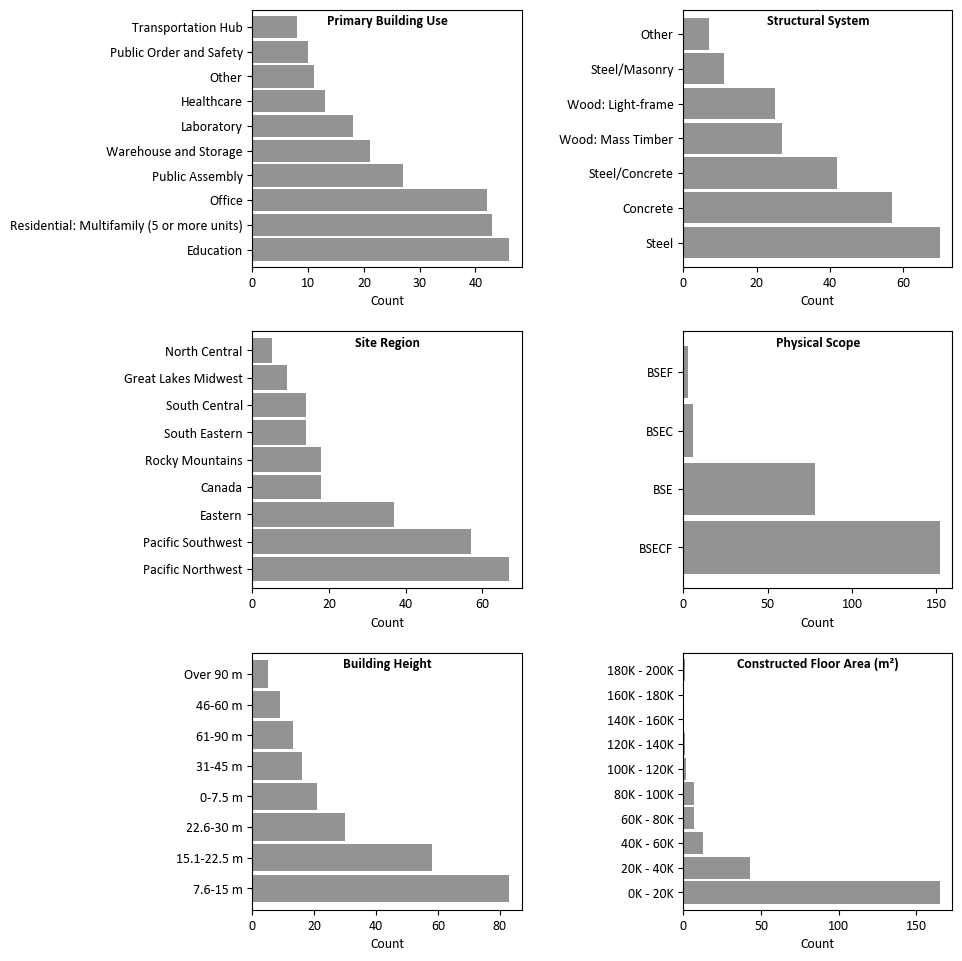

In [69]:
# Filter dataset for "New Construction" projects
wblca_meta_data_copy = wblca_meta_data[wblca_meta_data['bldg_proj_type'] == "New Construction"]

# Columns to analyze
categorical_features = ["bldg_prim_use_recat", "str_sys_summary", "site_region", "lca_phys_scope", "bldg_height"]
numerical_features = ["bldg_cfa"]  # This will work for any numerical feature

# Title mapping for clarity
title_mapping = {
    "bldg_prim_use_recat": "Primary Building Use",
    "str_sys_summary": "Structural System",
    "site_region": "Site Region",
    "lca_phys_scope": "Physical Scope",
    "bldg_height": "Building Height",
    "bldg_cfa": "Constructed Floor Area (m²)"
}

# Ensure numerical columns are numeric and round down to nearest 1000
for feature in numerical_features:
    wblca_meta_data_copy[feature] = pd.to_numeric(wblca_meta_data_copy[feature], errors="coerce")
    wblca_meta_data_copy[feature] = np.floor(wblca_meta_data_copy[feature] / 1000) * 1000

# Remove empty categorical features (those that are completely NaN)
valid_features = categorical_features + numerical_features
valid_features = [feature for feature in valid_features if wblca_meta_data_copy[feature].dropna().shape[0] > 0]

# Number of subplots needed
n_features = len(valid_features)
n_cols = 2  # Two columns for better layout
n_rows = (n_features // n_cols) + (n_features % n_cols > 0)  # Calculate required rows

# Figure size
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10))
axes = axes.flatten()  # Flatten for easy iteration

# Define a single consistent grayscale color
gray_color = "gray"  # All bars use this color

# Generate bar charts for categorical features (counts instead of percentages)
for ax, feature in zip(axes, categorical_features):
    counts = wblca_meta_data_copy[feature].value_counts(dropna=True)

    if not counts.empty:
        counts.plot(kind="barh", ax=ax, color=gray_color, edgecolor=None, alpha=0.85, width=0.9)
        ax.set_xlabel("Count")
        ax.set_ylabel("")  # Remove y-axis label
        ax.grid(False)  # Disable gridlines

        # Move title inside the chart area
        ax.text(
            0.5, 0.98, title_mapping.get(feature, feature.replace('_', ' ').title()),
            fontsize=10, fontweight="bold", color="black",
            ha="center", va="top", transform=ax.transAxes
        )
    else:
        ax.axis("off")  # Hide empty subplot

# Generate horizontal bar charts for numerical features (histograms with counts)
for ax, feature in zip(axes[len(categorical_features):], numerical_features):
    # Create bins for the numerical feature
    min_val, max_val = wblca_meta_data_copy[feature].min(), wblca_meta_data_copy[feature].max()
    bin_edges = np.linspace(min_val, max_val, 11)  # 10 bins

    counts, bins = np.histogram(wblca_meta_data_copy[feature].dropna(), bins=bin_edges)

    # Format bin labels as thousands (e.g., "80K-90K")
    bin_labels = [f"{int(bins[i]//1000)}K - {int(bins[i+1]//1000)}K" for i in range(len(bins)-1)]

    # Plot histogram with fixed bin labels
    pd.Series(counts, index=bin_labels).plot(kind="barh", ax=ax, color=gray_color, edgecolor=None, alpha=0.85, width=0.9)

    ax.set_xlabel("Count")
    ax.set_ylabel("")  # Remove y-axis label
    ax.grid(False)  # Disable gridlines

    ax.text(
        0.5, 0.98, title_mapping.get(feature, feature.replace('_', ' ').title()),
        fontsize=10, fontweight="bold", color="black",
        ha="center", va="top", transform=ax.transAxes
    )

# Hide any unused subplots
for ax in axes[n_features:]:
    ax.axis("off")

# Adjust layout with increased horizontal spacing
plt.subplots_adjust(left=0.2, right=0.9, top=0.95, bottom=0.05, wspace=0.6, hspace=0.25)

# Define the directory and filename where you want to save the image
save_path = "./Image Exports/Fig.1.Metadata.png"  # Change this to your desired directory

# Save the figure with a high resolution
fig.savefig(save_path, dpi=600, bbox_inches="tight")

print(f"Figure saved at: {save_path}")

# Show the plot
plt.show()


#### By building features

##### Box plots

Figure saved at: ./Image Exports/Fig.2.BoxPlots.png


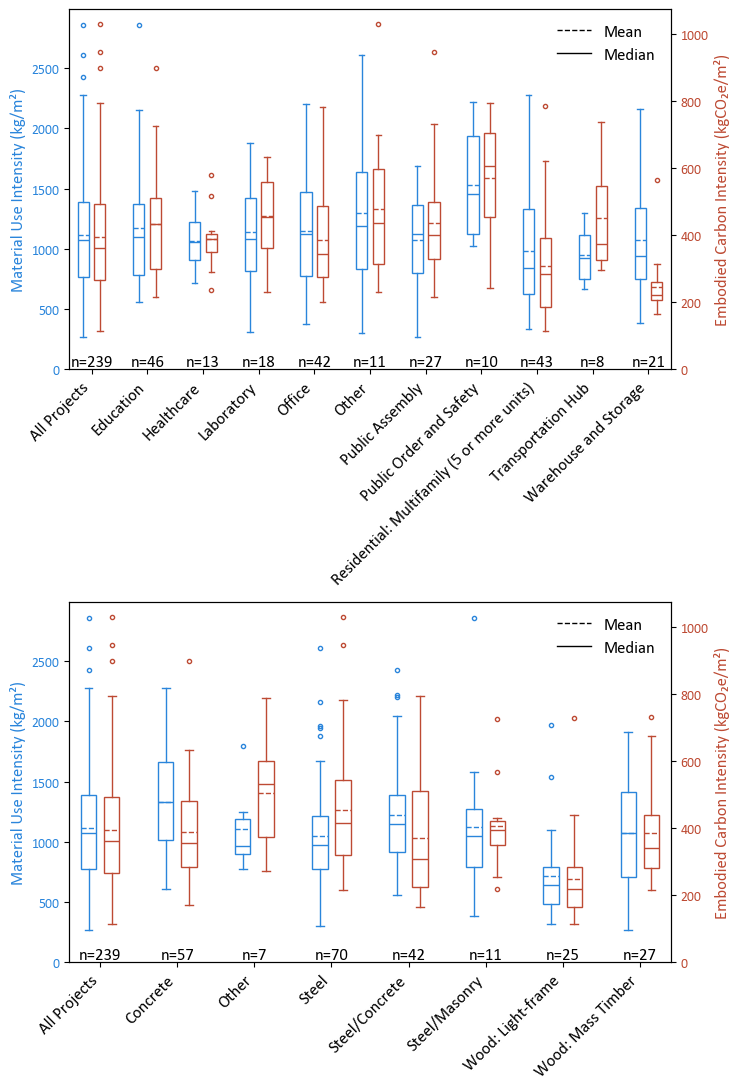

In [70]:

# Load the datasets
mui_eci_by_mat_group_bldg_prim_use = pd.read_csv('./Output Data/mui_eci_by_mat_group_bldg_prim_use.csv')
mui_eci_by_mat_group_str_sys_summary = pd.read_csv('./Output Data/mui_eci_by_mat_group_str_sys_summary.csv')

def plot_custom_boxplot(ax, x_positions, material_data, gwp_data, labels, data_counts, title):
    """ Creates a dual-axis boxplot with whiskers matching the box colors. """
    
    # Define box colors
    mui_color = "#2a85db"
    eci_color = "#bd4a33"

    # Material Use Intensity (MUI)
    bp1 = ax.boxplot(material_data, positions=x_positions - 0.3, widths=0.4, 
                    showmeans=True, meanline=True, meanprops={'color': '#2a85db'},
                    patch_artist=True, 
                    boxprops=dict(facecolor='white', color=mui_color), 
                    whiskerprops=dict(color=mui_color), 
                    capprops=dict(color=mui_color),
                    medianprops={'color': '#2a85db'},
                    showfliers=True,
                    flierprops=dict(marker='o', markersize=3, markeredgecolor=mui_color))  # Control outliers here

    ax.set_ylabel('Material Use Intensity (kg/m²)', color=mui_color, fontsize=12)
    ax.tick_params(axis='y', labelcolor=mui_color)
    ax.set_ylim(0)

    # Embodied Carbon Intensity (ECI)
    ax2 = ax.twinx()
    bp2 = ax2.boxplot(gwp_data, positions=x_positions + 0.3, widths=0.4, 
                    showmeans=True, meanline=True, meanprops={'color': '#bd4a33'},
                    patch_artist=True, 
                    boxprops=dict(facecolor='white', color=eci_color), 
                    whiskerprops=dict(color=eci_color), 
                    capprops=dict(color=eci_color),
                    medianprops={'color': '#bd4a33'},
                    showfliers=True,
                    flierprops=dict(marker='o', markersize=3, markeredgecolor=eci_color))  # Control outliers here

    ax2.set_ylabel('Embodied Carbon Intensity (kgCO₂e/m²)', color=eci_color, fontsize=12)
    ax2.tick_params(axis='y', labelcolor=eci_color)
    ax2.set_ylim(0)

    # Labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')

    # Data count annotations
    for i, label in enumerate(labels):
        ax.text(x_positions[i], 0.01 * ax.get_ylim()[1], f'n={data_counts[label]}', 
                ha='center', fontsize=12, color='black')

# --- Data Processing ---
def preprocess_data(df, group_col):
    df = df.copy()
    df['mui'] = df['mui'].replace(0, np.nan)
    df['eci'] = df['eci'].replace(0, np.nan)

    project_totals = df.groupby(['project_index', group_col]).agg({'mui': 'sum', 'eci': 'sum'}).reset_index()
    project_totals = project_totals[(project_totals['mui'] > 0) & (project_totals['eci'] > 0)]

    return project_totals[[group_col, 'mui']].dropna(), project_totals[[group_col, 'eci']].dropna()

def prepare_boxplot_data(material_data, gwp_data, group_col):
    unique_labels = sorted(material_data[group_col].unique())
    unique_labels.insert(0, "All Projects")

    material_plot_data = [material_data['mui'].values] + [
        material_data[material_data[group_col] == label]['mui'].values for label in unique_labels[1:]
    ]
    gwp_plot_data = [gwp_data['eci'].values] + [
        gwp_data[gwp_data[group_col] == label]['eci'].values for label in unique_labels[1:]
    ]
    data_counts = {"All Projects": len(material_data)} | material_data.groupby(group_col).size().to_dict()

    return unique_labels, material_plot_data, gwp_plot_data, data_counts

# Process datasets
material_data_bldg, gwp_data_bldg = preprocess_data(mui_eci_by_mat_group_bldg_prim_use, 'bldg_prim_use_recat')
unique_labels_bldg, material_plot_bldg, gwp_plot_bldg, data_counts_bldg = prepare_boxplot_data(material_data_bldg, gwp_data_bldg, 'bldg_prim_use_recat')

material_data_str, gwp_data_str = preprocess_data(mui_eci_by_mat_group_str_sys_summary, 'str_sys_summary')
unique_labels_str, material_plot_str, gwp_plot_str, data_counts_str = prepare_boxplot_data(material_data_str, gwp_data_str, 'str_sys_summary')

# --- Plot Configuration ---
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7.5, 11))

# --- Building Use Plot ---
x_positions_bldg = np.arange(len(unique_labels_bldg)) * 2.0
plot_custom_boxplot(axes[0], x_positions_bldg, material_plot_bldg, gwp_plot_bldg, unique_labels_bldg, data_counts_bldg, "")

# --- Structural System Plot ---
x_positions_str = np.arange(len(unique_labels_str)) * 2.0
plot_custom_boxplot(axes[1], x_positions_str, material_plot_str, gwp_plot_str, unique_labels_str, data_counts_str, "")

# --- Legend ---
legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', linewidth=1, label='Mean'),
    Line2D([0], [0], color='black', linestyle='-', linewidth=1, label='Median')
]
axes[0].legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=12)
axes[1].legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=12)

plt.tight_layout()

# Define the directory and filename where you want to save the image
save_path = "./Image Exports/Fig.2.BoxPlots.png"  # Change this to your desired directory

# Save the figure with a high resolution
fig.savefig(save_path, dpi=600, bbox_inches="tight")

print(f"Figure saved at: {save_path}")

# Show the plot
plt.show()


##### Bar charts

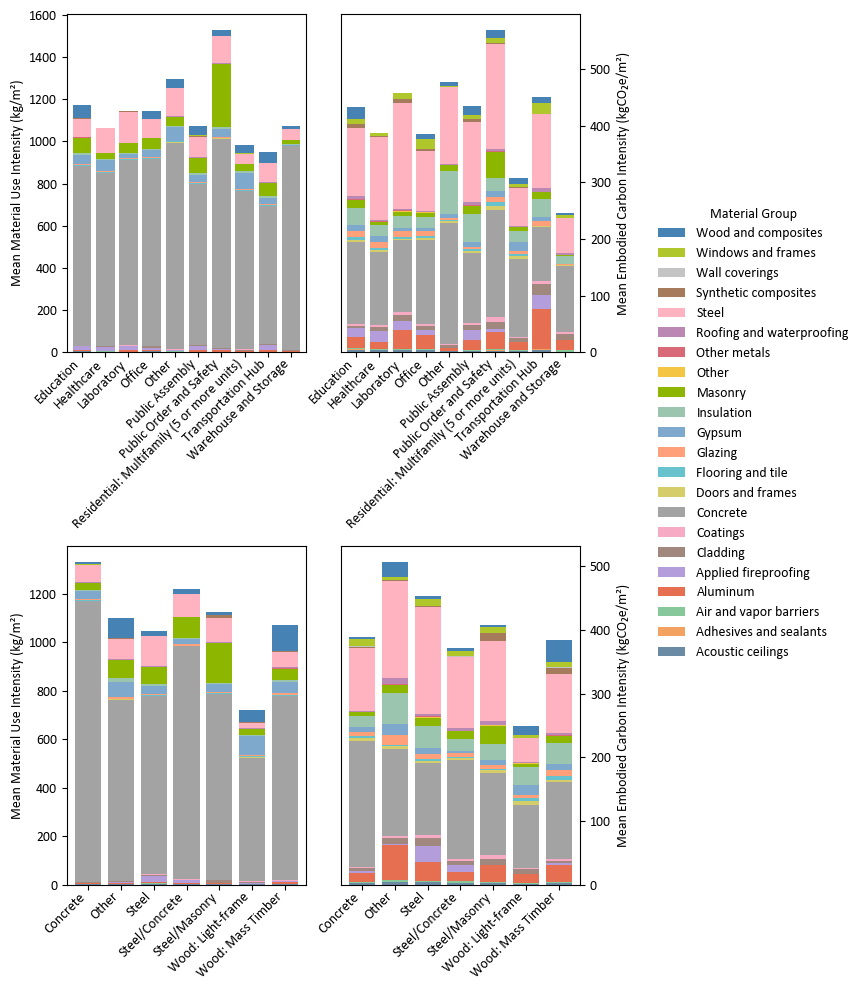

In [71]:
# Load the datasets
mui_eci_by_mat_group_bldg_prim_use = pd.read_csv('./Output Data/mui_eci_by_mat_group_bldg_prim_use.csv')
mui_eci_by_mat_group_str_sys_summary = pd.read_csv('./Output Data/mui_eci_by_mat_group_str_sys_summary.csv')

# Define the colors
my_colors = [
    "#6b8ba4", "#f4a261", "#86c89a", "#e76f51", "#b39ddb", "#a1887f",
    "#f7aac3", "#a3a3a3", "#d4cd6a", "#66c2cd", "#ffa07a", "#7ea9cc",
    "#9cc5b0", "#8db600", "#f4c542", "#d86a78", "#bb88b4", "#ffb3c1",
    "#a67b5b", "#c4c4c4", "#b0c72c", "#4682b4"
]

# --- Data Processing for mui_eci_by_mat_group_bldg_prim_use ---

# Filter data for New Construction only
filtered_data = mui_eci_by_mat_group_bldg_prim_use[
    (mui_eci_by_mat_group_bldg_prim_use['bldg_proj_type'] == 'New Construction')
].copy()

# Replace zeros and blanks with NaN for relevant columns
filtered_data['mui'] = filtered_data['mui'].replace(0, np.nan)
filtered_data['eci'] = filtered_data['eci'].replace(0, np.nan)

# Step 1: Calculate total material use intensity and total GWP intensity per project_index
project_totals_mui = (
    filtered_data.groupby('project_index')['mui']
    .sum()
    .reset_index()
    .rename(columns={'mui': 'total_mui'})
)

project_totals_eci = (
    filtered_data.groupby('project_index')['eci']
    .sum()
    .reset_index()
    .rename(columns={'eci': 'total_eci'})
)

# Step 2: Calculate mean total intensity by building use
project_totals_mui = project_totals_mui.merge(
    filtered_data[['project_index', 'bldg_prim_use_recat']].drop_duplicates(),
    on='project_index',
    how='left'
)

project_totals_eci = project_totals_eci.merge(
    filtered_data[['project_index', 'bldg_prim_use_recat']].drop_duplicates(),
    on='project_index',
    how='left'
)

mean_totals_by_use_mui = (
    project_totals_mui.groupby('bldg_prim_use_recat')['total_mui']
    .mean()
    .reset_index()
    .rename(columns={'total_mui': 'mean_total_mui'})
)

mean_totals_by_use_eci = (
    project_totals_eci.groupby('bldg_prim_use_recat')['total_eci']
    .mean()
    .reset_index()
    .rename(columns={'total_eci': 'mean_total_eci'})
)

# Step 3: Calculate contributions per project_index
contributions_mui = (
    filtered_data.groupby(['project_index', 'mat_group'])['mui']
    .sum()
    .reset_index()
)

contributions_eci = (
    filtered_data.groupby(['project_index', 'mat_group'])['eci']
    .sum()
    .reset_index()
)

contributions_mui = contributions_mui.merge(
    project_totals_mui,
    on='project_index',
    how='left'
)

contributions_eci = contributions_eci.merge(
    project_totals_eci,
    on='project_index',
    how='left'
)

contributions_mui['mat_group_contribution'] = (
    contributions_mui['mui'] / contributions_mui['total_mui']
)

contributions_eci['mat_group_contribution'] = (
    contributions_eci['eci'] / contributions_eci['total_eci']
)

# Step 4: Calculate mean contributions by bldg_prim_use_recat
contribution_means_mui = (
    contributions_mui.groupby(['bldg_prim_use_recat', 'mat_group'])['mat_group_contribution']
    .mean()
    .reset_index()
)

contribution_means_eci = (
    contributions_eci.groupby(['bldg_prim_use_recat', 'mat_group'])['mat_group_contribution']
    .mean()
    .reset_index()
)

# Step 5: Normalize contributions
contribution_means_mui['mat_group_contribution_normalized'] = contribution_means_mui.groupby('bldg_prim_use_recat')['mat_group_contribution'].transform(lambda x: x / x.sum())

contribution_means_eci['mat_group_contribution_normalized'] = contribution_means_eci.groupby('bldg_prim_use_recat')['mat_group_contribution'].transform(lambda x: x / x.sum())

# Step 6: Break down mean totals using normalized contributions
contribution_means_mui = contribution_means_mui.merge(
    mean_totals_by_use_mui,
    on='bldg_prim_use_recat',
    how='left'
)

contribution_means_eci = contribution_means_eci.merge(
    mean_totals_by_use_eci,
    on='bldg_prim_use_recat',
    how='left'
)

contribution_means_mui['mat_group_contribution_to_total'] = (
    contribution_means_mui['mat_group_contribution_normalized'] * contribution_means_mui['mean_total_mui']
)

contribution_means_eci['mat_group_contribution_to_total'] = (
    contribution_means_eci['mat_group_contribution_normalized'] * contribution_means_eci['mean_total_eci']
)

# --- Data Processing for mui_eci_by_mat_group_str_sys_summary ---

# Filter data for New Construction only
filtered_data_code2 = mui_eci_by_mat_group_str_sys_summary.copy()

# Replace zeros and blanks with NaN for relevant columns
filtered_data_code2['mui'] = filtered_data_code2['mui'].replace(0, np.nan)
filtered_data_code2['eci'] = filtered_data_code2['eci'].replace(0, np.nan)

# Step 1: Calculate total material use intensity and total GWP intensity per project_index
project_totals_mui_code2 = (
    filtered_data_code2.groupby('project_index')['mui']
    .sum()
    .reset_index()
    .rename(columns={'mui': 'total_mui'})
)

project_totals_eci_code2 = (
    filtered_data_code2.groupby('project_index')['eci']
    .sum()
    .reset_index()
    .rename(columns={'eci': 'total_eci'})
)

# Step 2: Calculate mean total intensity by building use
project_totals_mui_code2 = project_totals_mui_code2.merge(
    filtered_data_code2[['project_index', 'str_sys_summary']].drop_duplicates(),
    on='project_index',
    how='left'
)

project_totals_eci_code2 = project_totals_eci_code2.merge(
    filtered_data_code2[['project_index', 'str_sys_summary']].drop_duplicates(),
    on='project_index',
    how='left'
)

mean_totals_by_use_mui_code2 = (
    project_totals_mui_code2.groupby('str_sys_summary')['total_mui']
    .mean()
    .reset_index()
    .rename(columns={'total_mui': 'mean_total_mui'})
)

mean_totals_by_use_eci_code2 = (
    project_totals_eci_code2.groupby('str_sys_summary')['total_eci']
    .mean()
    .reset_index()
    .rename(columns={'total_eci': 'mean_total_eci'})
)

# Step 3: Calculate contributions per project_index
contributions_mui_code2 = (
    filtered_data_code2.groupby(['project_index', 'mat_group'])['mui']
    .sum()
    .reset_index()
)

contributions_eci_code2 = (
    filtered_data_code2.groupby(['project_index', 'mat_group'])['eci']
    .sum()
    .reset_index()
)

contributions_mui_code2 = contributions_mui_code2.merge(
    project_totals_mui_code2,
    on='project_index',
    how='left'
)

contributions_eci_code2 = contributions_eci_code2.merge(
    project_totals_eci_code2,
    on='project_index',
    how='left'
)

contributions_mui_code2['mat_group_contribution'] = (
    contributions_mui_code2['mui'] / contributions_mui_code2['total_mui']
)

contributions_eci_code2['mat_group_contribution'] = (
    contributions_eci_code2['eci'] / contributions_eci_code2['total_eci']
)

# Step 4: Calculate mean contributions by str_sys_summary
contribution_means_mui_code2 = (
    contributions_mui_code2.groupby(['str_sys_summary', 'mat_group'])['mat_group_contribution']
    .mean()
    .reset_index()
)

contribution_means_eci_code2 = (
    contributions_eci_code2.groupby(['str_sys_summary', 'mat_group'])['mat_group_contribution']
    .mean()
    .reset_index()
)

# Step 5: Normalize contributions
contribution_means_mui_code2['mat_group_contribution_normalized'] = contribution_means_mui_code2.groupby('str_sys_summary')['mat_group_contribution'].transform(lambda x: x / x.sum())

contribution_means_eci_code2['mat_group_contribution_normalized'] = contribution_means_eci_code2.groupby('str_sys_summary')['mat_group_contribution'].transform(lambda x: x / x.sum())

# Step 6: Break down mean totals using normalized contributions
contribution_means_mui_code2 = contribution_means_mui_code2.merge(
    mean_totals_by_use_mui_code2,
    on='str_sys_summary',
    how='left'
)

contribution_means_eci_code2 = contribution_means_eci_code2.merge(
    mean_totals_by_use_eci_code2,
    on='str_sys_summary',
    how='left'
)

contribution_means_mui_code2['mat_group_contribution_to_total'] = (
    contribution_means_mui_code2['mat_group_contribution_normalized'] * contribution_means_mui_code2['mean_total_mui']
)

contribution_means_eci_code2['mat_group_contribution_to_total'] = (
    contribution_means_eci_code2['mat_group_contribution_normalized'] * contribution_means_eci_code2['mean_total_eci']
)

# Concatenate the datasets for plotting
pivot_data_mui_use = contribution_means_mui.pivot(index='bldg_prim_use_recat', columns='mat_group', values='mat_group_contribution_to_total').fillna(0)
pivot_data_eci_use = contribution_means_eci.pivot(index='bldg_prim_use_recat', columns='mat_group', values='mat_group_contribution_to_total').fillna(0)

pivot_data_mui_str = contribution_means_mui_code2.pivot(index='str_sys_summary', columns='mat_group', values='mat_group_contribution_to_total').fillna(0)
pivot_data_eci_str = contribution_means_eci_code2.pivot(index='str_sys_summary', columns='mat_group', values='mat_group_contribution_to_total').fillna(0)

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(6.5, 10))  # Adjust figsize as needed

# Plot MUI for building use
pivot_data_mui_use.plot(kind='bar', stacked=True, ax=axes[0, 0], color=my_colors, edgecolor='none', width=0.8)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Mean Material Use Intensity (kg/m²)", fontsize=10)
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45, ha='right', fontsize=10)
axes[0, 0].set_title("")
axes[0, 0].get_legend().remove()

# Plot ECI for building use
pivot_data_eci_use.plot(kind='bar', stacked=True, ax=axes[0, 1], color=my_colors, edgecolor='none', width=0.8)
axes[0, 1].set_xlabel("")
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right', fontsize=10)
axes[0, 1].yaxis.tick_right()
axes[0, 1].yaxis.set_label_position("right")
axes[0, 1].set_ylabel("Mean Embodied Carbon Intensity (kgCO₂e/m²)", fontsize=10)
axes[0, 1].set_title("")
axes[0, 1].get_legend().remove()

# Plot MUI for structural system
pivot_data_mui_str.plot(kind='bar', stacked=True, ax=axes[1, 0], color=my_colors, edgecolor='none', width=0.8)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Mean Material Use Intensity (kg/m²)", fontsize=10)
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right', fontsize=10)
axes[1, 0].set_title("")
axes[1, 0].get_legend().remove()

# Plot ECI for structural system
pivot_data_eci_str.plot(kind='bar', stacked=True, ax=axes[1, 1], color=my_colors, edgecolor='none', width=0.8)
axes[1, 1].set_xlabel("")
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right', fontsize=10)
axes[1, 1].yaxis.tick_right()
axes[1, 1].yaxis.set_label_position("right")
axes[1, 1].set_ylabel("Mean Embodied Carbon Intensity (kgCO₂e/m²)", fontsize=10)
axes[1, 1].set_title("")
axes[1, 1].get_legend().remove()

# Single legend for all plots
handles, labels = axes[0, 0].get_legend_handles_labels()
sorted_indices = sorted(range(len(labels)), key=lambda k: labels[k], reverse=True)
sorted_labels = [labels[i] for i in sorted_indices]
sorted_handles = [handles[i] for i in sorted_indices]
fig.legend(sorted_handles, sorted_labels, title="Material Group", bbox_to_anchor=(1., 0.8), loc='upper left', fontsize=10, frameon=False)

# Adjust x-axis label position for all axes
for ax in axes.flat:
    ax.tick_params(axis='x', pad=0.5)

# Adjust layout
plt.tight_layout(w_pad=0.01)

# Show the plot
plt.show()

### Material-level analysis

#### Material metadata: category mappings and flows

##### Generic mapping based on counts

In [72]:
# Assuming merged_df is loaded and filtered for the specific life cycle stage and project type
filtered_df = merged_df[(merged_df['life_cycle_stage'] == 'A1-A3') & (merged_df['bldg_proj_type'] == 'New Construction')]

# Group data to understand the unique connections
connections = filtered_df.groupby(['mat_type', 'mat_group']).size().reset_index(name='Count')

# Create a count of unique mat_groups for each mat_type and vice versa
mat_type_to_group = connections.groupby('mat_type')['mat_group'].nunique().reset_index(name='Unique_Outflows')
mat_group_to_type = connections.groupby('mat_group')['mat_type'].nunique().reset_index(name='Unique_Inflows')

# Merge back to the connections to get the inflow and outflow counts for each connection
sankey_data = connections.merge(mat_type_to_group, on='mat_type')
sankey_data = sankey_data.merge(mat_group_to_type, on='mat_group')

# Define the two subsets based on mat_group names
left_mat_groups = ["Acoustic ceilings", "Adhesives and sealants", "Air and vapor barriers", "Aluminum", "Cladding", "Doors and frames", "Windows and frames", "Applied fireproofing", "Roofing and waterproofing", "Other metals", "Masonry"]

# Split data into two subsets
sankey_left = sankey_data[sankey_data['mat_group'].isin(left_mat_groups)].copy()
sankey_right = sankey_data[~sankey_data['mat_group'].isin(left_mat_groups)].copy()

# Function to create Sankey chart traces
def create_sankey_trace(sankey_data):
    mat_type_ids = {mat_type: i for i, mat_type in enumerate(sankey_data['mat_type'].unique())}
    mat_group_ids = {mat_group: i + len(mat_type_ids) for i, mat_group in enumerate(sankey_data['mat_group'].unique())}

    sankey_data.loc[:, 'source'] = sankey_data['mat_type'].map(mat_type_ids)
    sankey_data.loc[:, 'target'] = sankey_data['mat_group'].map(mat_group_ids)
    sankey_data.loc[:, 'value'] = sankey_data['Unique_Outflows']

    node_colors = ['#FF6692', '#B6E880', '#FF97FF', '#FECB52', '#EF553B', '#00CC96', '#AB63FA', '#19D3F3', '#FFA15A', '#636EFA'] * (len(mat_type_ids) + len(mat_group_ids) // 10 + 1)

    return go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=[*mat_type_ids.keys(), *mat_group_ids.keys()],
            color=node_colors[:len(mat_type_ids) + len(mat_group_ids)]
        ),
        link=dict(
            source=sankey_data['source'],
            target=sankey_data['target'],
            value=sankey_data['value'],
            color='rgba(180,180,180,0.5)'
        ))

# Create subplots layout with one row and two columns
fig = sp.make_subplots(rows=1, cols=2, subplot_titles=("", ""),
                        specs=[[{"type": "sankey"}, {"type": "sankey"}]],
                        column_widths=[0.45, 0.45],  # Adjust space between columns
                        horizontal_spacing=0.03)  # Control distance between two plots

# Add Sankey diagrams to the respective subplot positions
fig.add_trace(create_sankey_trace(sankey_left), row=1, col=1)
fig.add_trace(create_sankey_trace(sankey_right), row=1, col=2)

# Update layout with margin control
fig.update_layout(
    title_text="",
    font_size=11,
    width=750,
    height=950,
    margin=dict(l=5, r=5, t=10, b=10)  # Adjust left, right, top, bottom margins
)

fig.show(config={'toImageButtonOptions': {'scale': 3}})  # Increase scale for higher resolution


In [73]:
filtered_df = merged_df[(merged_df['life_cycle_stage'] == 'A1-A3') & (merged_df['bldg_proj_type'] == 'New Construction')]

# Count unique mat_groups for each mat_type
mat_type_to_group_count = filtered_df.groupby('str_sys_summary')['mat_group'].nunique()

# Count unique mat_types for each mat_group
mat_group_to_type_count = filtered_df.groupby('mat_group')['str_sys_summary'].nunique()

# Check if all values in these series are 1, which indicates uniqueness
mat_type_unique_mapping = (mat_type_to_group_count == 1).all()
mat_group_unique_mapping = (mat_group_to_type_count == 1).all()

mat_type_unique_mapping, mat_group_unique_mapping


(False, False)

#### `mat_group` MUI and ECI distributions across projects

C:\Users\ashtiani\AppData\Local\Temp\ipykernel_25848\582588794.py:30: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\ashtiani\AppData\Local\Temp\ipykernel_25848\582588794.py:44: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Figure saved at: ./Image Exports/Fig.4.MaterialBoxplots.png


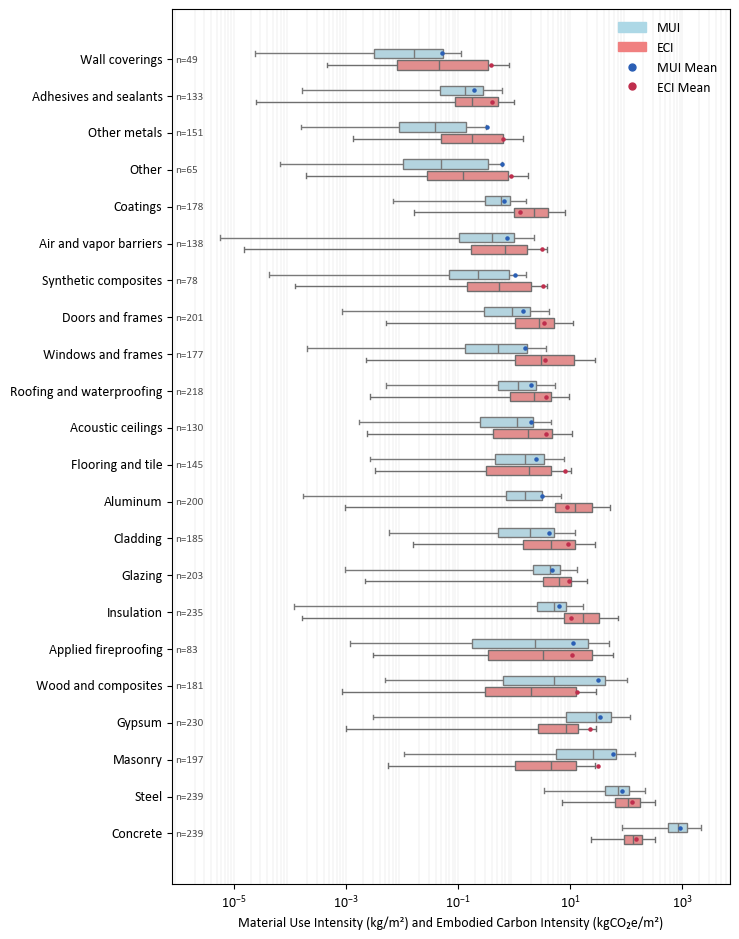

In [74]:
def process_and_plot_combined_metrics_static(df, category_column, title_prefix, width=10, height=15, save_path=None):
    """
    Processes and plots combined metrics (mui and eci) using static box plots with averages, excluding outliers.
    """
    df_filtered = df[df['bldg_proj_type'] == 'New Construction'].copy()

    category_stats_mui = df_filtered.groupby(category_column)['mui'].agg(['median', 'mean', 'count']).sort_values('mean')
    category_stats_eci = df_filtered.groupby(category_column)['eci'].agg(['median', 'mean']).sort_values('mean')

    df_filtered[category_column] = pd.Categorical(df_filtered[category_column], categories=category_stats_mui.index, ordered=True)

    plt.figure(figsize=(width, height))

    # Calculate positions for mui and eci boxplots with increased spacing
    spacing = 1.4  # Adjust this value to control spacing
    positions_mui = [i * spacing - 0.22 for i in range(len(category_stats_mui.index))]
    positions_eci = [i * spacing + 0.22 for i in range(len(category_stats_eci.index))]

    # Box plot for MUI (excluding zeros visually)
    sns.boxplot(
        x='mui', 
        y=category_column, 
        data=df_filtered[df_filtered['mui'] > 0], 
        color='lightblue', 
        positions=positions_mui, 
        width=0.35, 
        fliersize=0
    )
    # Scatter plot for MUI average (excluding zeros visually)
    mui_means_no_zero = df_filtered[df_filtered['mui'] > 0].groupby(category_column)['mui'].mean().reindex(category_stats_mui.index)
    plt.scatter(mui_means_no_zero, positions_mui, color='#2a5fb5', marker='o', s=5, label='MUI Average', zorder=5)

    # Box plot for ECI (excluding zeros visually)
    sns.boxplot(
        x='eci', 
        y=category_column, 
        data=df_filtered[df_filtered['eci'] > 0], 
        color='lightcoral', 
        positions=positions_eci, 
        width=0.35, 
        fliersize=0
    )
    # Scatter plot for ECI average (excluding zeros visually)
    eci_means_no_zero = df_filtered[df_filtered['eci'] > 0].groupby(category_column)['eci'].mean().reindex(category_stats_eci.index)
    plt.scatter(eci_means_no_zero, positions_eci, color='#bf2e4d', marker='o', s=5, label='ECI Average', zorder=5)

    # Create custom legend handles
    legend_handles = [
        Patch(color='lightblue', label='MUI'),
        Patch(color='lightcoral', label='ECI'),
        plt.Line2D([0], [0], marker='o', color='#2a5fb5', markersize=5, linestyle='None', label='MUI Mean'),
        plt.Line2D([0], [0], marker='o', color='#bf2e4d', markersize=5, linestyle='None', label='ECI Mean'),
    ]
    
    # Calculate centered positions for y-ticks
    positions_center = [i * spacing for i in range(len(category_stats_mui.index))]  
    plt.yticks(ticks=positions_center, labels=category_stats_mui.index, va='center')  # Centered y-ticks
    
    # Annotate counts aligned clearly within log-scale chart
    annotation_x = 9*1e-7  # x=0.00001
    for pos, count in zip(positions_center, category_stats_mui['count']):
        plt.text(annotation_x, pos, f'n={count}', va='center', ha='left', fontsize=8, color='black', alpha=0.7)
    
    plt.title("")
    plt.xlabel("Material Use Intensity (kg/m²) and Embodied Carbon Intensity (kgCO₂e/m²)")
    plt.ylabel("")
    plt.xscale('log')


    # Customize x-axis ticks and grid
    ax = plt.gca()
    ax.xaxis.set_major_locator(LogLocator(base=10.0))  # Keep only major ticks
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs="auto", numticks=10))  # Keep minor gridlines
    ax.xaxis.set_minor_formatter(NullFormatter())  # Hide minor tick labels
    ax.tick_params(axis='x', which='minor', length=0)  # Remove minor ticks but keep minor gridlines
    plt.grid(True, which='both', axis='x', linestyle='-', linewidth=0.2, alpha=0.7)  # Dashed grid for readability

    plt.legend(handles=legend_handles, loc='upper right', frameon=False)
    plt.tight_layout()
    plt.yticks(ticks=positions_center, labels=category_stats_mui.index, va='center')  # Centered y-ticks
    plt.xlim(left=8*1e-7)


    # Save the figure if a save_path is provided
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")
        print(f"Figure saved at: {save_path}")
    
    plt.show()

# Load datasets
df_mat_group = pd.read_csv('./Output Data/mui_eci_by_mat_group_bldg_prim_use.csv')

# Define save path
save_path = "./Image Exports/Fig.4.MaterialBoxplots.png"  # Adjust to your preferred directory

# Process and plot with saving option
process_and_plot_combined_metrics_static(df_mat_group, 'mat_group', 'Material Group', width=7.5, height=9.5, save_path=save_path)


##### Re-ordered material group categories per building characteristics

Figure saved at: ./Image Exports/Fig.3.BarCharts_sorted_by_median_mui.png


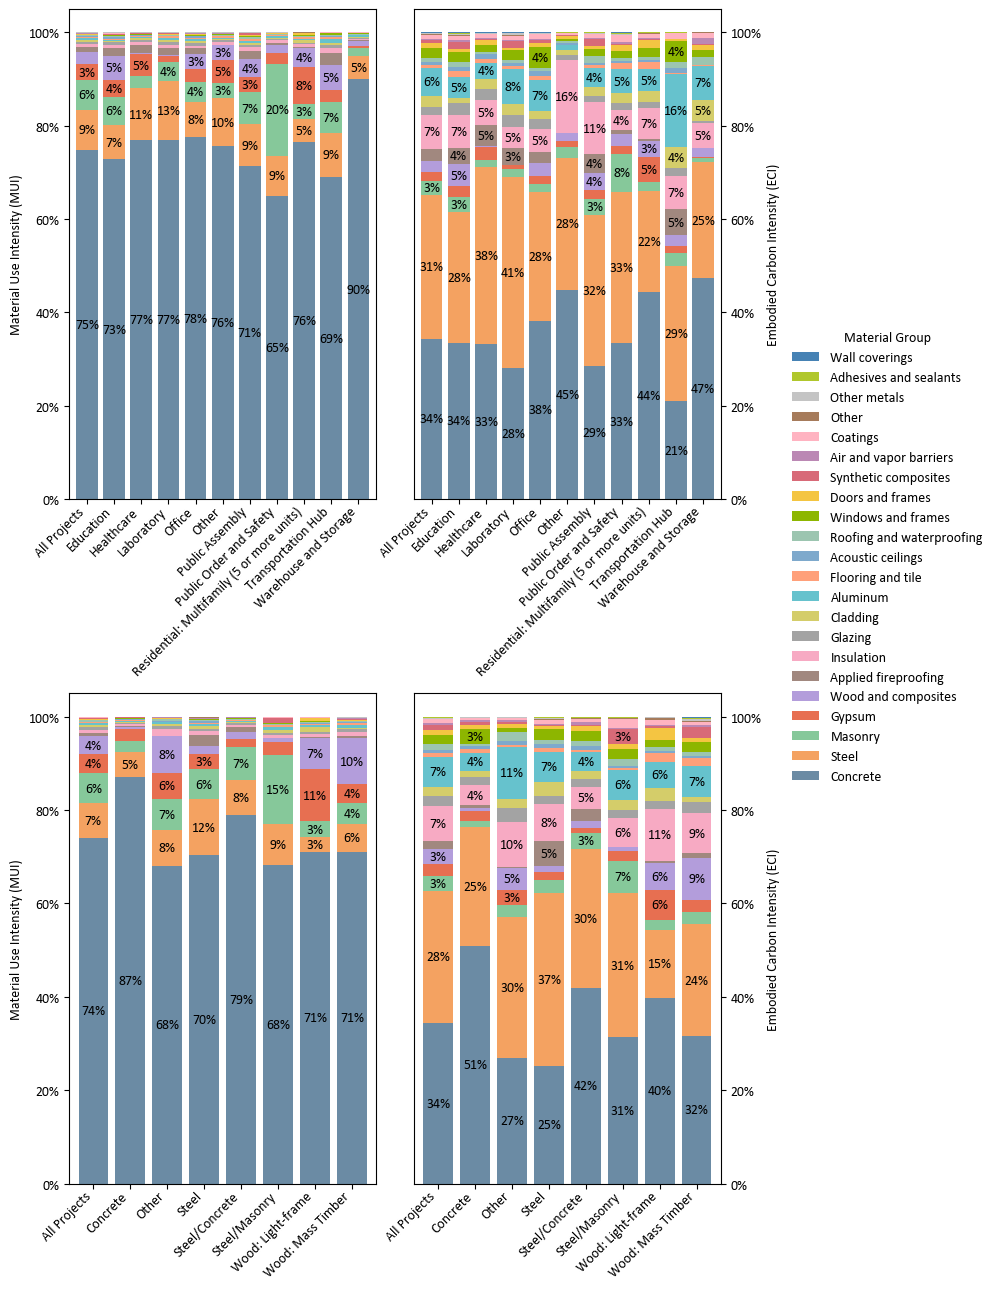

In [75]:

# Load the datasets
mui_eci_by_mat_group_bldg_prim_use = pd.read_csv('./Output Data/mui_eci_by_mat_group_bldg_prim_use.csv')
mui_eci_by_mat_group_str_sys_summary = pd.read_csv('./Output Data/mui_eci_by_mat_group_str_sys_summary.csv')

# Define the colors
my_colors = [
    "#6b8ba4", "#f4a261", "#86c89a", "#e76f51", "#b39ddb", "#a1887f",
    "#f7aac3", "#a3a3a3", "#d4cd6a", "#66c2cd", "#ffa07a", "#7ea9cc",
    "#9cc5b0", "#8db600", "#f4c542", "#d86a78", "#bb88b4", "#ffb3c1",
    "#a67b5b", "#c4c4c4", "#b0c72c", "#4682b4"
]

# --- Data Processing for mui_eci_by_mat_group_bldg_prim_use ---

# Filter data for New Construction only
filtered_data = mui_eci_by_mat_group_bldg_prim_use[
    (mui_eci_by_mat_group_bldg_prim_use['bldg_proj_type'] == 'New Construction')
].copy()

# Replace zeros and blanks with NaN for relevant columns
filtered_data['mui'] = filtered_data['mui'].replace(0, np.nan)
filtered_data['eci'] = filtered_data['eci'].replace(0, np.nan)

# Step 1: Calculate total material use intensity and total GWP intensity per project_index
project_totals_mui = (
    filtered_data.groupby('project_index')['mui']
    .sum()
    .reset_index()
    .rename(columns={'mui': 'total_mui'})
)

project_totals_eci = (
    filtered_data.groupby('project_index')['eci']
    .sum()
    .reset_index()
    .rename(columns={'eci': 'total_eci'})
)

# Step 2: Calculate mean total intensity by building use
project_totals_mui = project_totals_mui.merge(
    filtered_data[['project_index', 'bldg_prim_use_recat']].drop_duplicates(),
    on='project_index',
    how='left'
)

project_totals_eci = project_totals_eci.merge(
    filtered_data[['project_index', 'bldg_prim_use_recat']].drop_duplicates(),
    on='project_index',
    how='left'
)

mean_totals_by_use_mui = (
    project_totals_mui.groupby('bldg_prim_use_recat')['total_mui']
    .mean()
    .reset_index()
    .rename(columns={'total_mui': 'mean_total_mui'})
)

mean_totals_by_use_eci = (
    project_totals_eci.groupby('bldg_prim_use_recat')['total_eci']
    .mean()
    .reset_index()
    .rename(columns={'total_eci': 'mean_total_eci'})
)

# Step 3: Calculate contributions per project_index
contributions_mui = (
    filtered_data.groupby(['project_index', 'mat_group'])['mui']
    .sum()
    .reset_index()
)

contributions_eci = (
    filtered_data.groupby(['project_index', 'mat_group'])['eci']
    .sum()
    .reset_index()
)

contributions_mui = contributions_mui.merge(
    project_totals_mui,
    on='project_index',
    how='left'
)

contributions_eci = contributions_eci.merge(
    project_totals_eci,
    on='project_index',
    how='left'
)

contributions_mui['mat_group_contribution'] = (
    contributions_mui['mui'] / contributions_mui['total_mui']
)

contributions_eci['mat_group_contribution'] = (
    contributions_eci['eci'] / contributions_eci['total_eci']
)

# Step 4: Calculate mean contributions by bldg_prim_use_recat
contribution_means_mui = (
    contributions_mui.groupby(['bldg_prim_use_recat', 'mat_group'])['mat_group_contribution']
    .mean()
    .reset_index()
)

contribution_means_eci = (
    contributions_eci.groupby(['bldg_prim_use_recat', 'mat_group'])['mat_group_contribution']
    .mean()
    .reset_index()
)

# Step 5: Normalize contributions
contribution_means_mui['mat_group_contribution_normalized'] = contribution_means_mui.groupby('bldg_prim_use_recat')['mat_group_contribution'].transform(lambda x: x / x.sum())

contribution_means_eci['mat_group_contribution_normalized'] = contribution_means_eci.groupby('bldg_prim_use_recat')['mat_group_contribution'].transform(lambda x: x / x.sum())

# Step 6: Break down mean totals using normalized contributions
contribution_means_mui = contribution_means_mui.merge(
    mean_totals_by_use_mui,
    on='bldg_prim_use_recat',
    how='left'
)

contribution_means_eci = contribution_means_eci.merge(
    mean_totals_by_use_eci,
    on='bldg_prim_use_recat',
    how='left'
)

contribution_means_mui['mat_group_contribution_to_total'] = (
    contribution_means_mui['mat_group_contribution_normalized'] * contribution_means_mui['mean_total_mui']
)

contribution_means_eci['mat_group_contribution_to_total'] = (
    contribution_means_eci['mat_group_contribution_normalized'] * contribution_means_eci['mean_total_eci']
)

# --- Data Processing for mui_eci_by_mat_group_str_sys_summary ---

# Filter data for New Construction only
filtered_data_code2 = mui_eci_by_mat_group_str_sys_summary.copy()

# Replace zeros and blanks with NaN for relevant columns
filtered_data_code2['mui'] = filtered_data_code2['mui'].replace(0, np.nan)
filtered_data_code2['eci'] = filtered_data_code2['eci'].replace(0, np.nan)

# Step 1: Calculate total material use intensity and total GWP intensity per project_index
project_totals_mui_code2 = (
    filtered_data_code2.groupby('project_index')['mui']
    .sum()
    .reset_index()
    .rename(columns={'mui': 'total_mui'})
)

project_totals_eci_code2 = (
    filtered_data_code2.groupby('project_index')['eci']
    .sum()
    .reset_index()
    .rename(columns={'eci': 'total_eci'})
)

# Step 2: Calculate mean total intensity by building use
project_totals_mui_code2 = project_totals_mui_code2.merge(
    filtered_data_code2[['project_index', 'str_sys_summary']].drop_duplicates(),
    on='project_index',
    how='left'
)

project_totals_eci_code2 = project_totals_eci_code2.merge(
    filtered_data_code2[['project_index', 'str_sys_summary']].drop_duplicates(),
    on='project_index',
    how='left'
)

mean_totals_by_use_mui_code2 = (
    project_totals_mui_code2.groupby('str_sys_summary')['total_mui']
    .mean()
    .reset_index()
    .rename(columns={'total_mui': 'mean_total_mui'})
)

mean_totals_by_use_eci_code2 = (
    project_totals_eci_code2.groupby('str_sys_summary')['total_eci']
    .mean()
    .reset_index()
    .rename(columns={'total_eci': 'mean_total_eci'})
)

# Step 3: Calculate contributions per project_index
contributions_mui_code2 = (
    filtered_data_code2.groupby(['project_index', 'mat_group'])['mui']
    .sum()
    .reset_index()
)

contributions_eci_code2 = (
    filtered_data_code2.groupby(['project_index', 'mat_group'])['eci']
    .sum()
    .reset_index()
)

contributions_mui_code2 = contributions_mui_code2.merge(
    project_totals_mui_code2,
    on='project_index',
    how='left'
)

contributions_eci_code2 = contributions_eci_code2.merge(
    project_totals_eci_code2,
    on='project_index',
    how='left'
)

contributions_mui_code2['mat_group_contribution'] = (
    contributions_mui_code2['mui'] / contributions_mui_code2['total_mui']
)

contributions_eci_code2['mat_group_contribution'] = (
    contributions_eci_code2['eci'] / contributions_eci_code2['total_eci']
)

# Step 4: Calculate mean contributions by str_sys_summary
contribution_means_mui_code2 = (
    contributions_mui_code2.groupby(['str_sys_summary', 'mat_group'])['mat_group_contribution']
    .mean()
    .reset_index()
)

contribution_means_eci_code2 = (
    contributions_eci_code2.groupby(['str_sys_summary', 'mat_group'])['mat_group_contribution']
    .mean()
    .reset_index()
)

# Step 5: Normalize contributions
contribution_means_mui_code2['mat_group_contribution_normalized'] = contribution_means_mui_code2.groupby('str_sys_summary')['mat_group_contribution'].transform(lambda x: x / x.sum())

contribution_means_eci_code2['mat_group_contribution_normalized'] = contribution_means_eci_code2.groupby('str_sys_summary')['mat_group_contribution'].transform(lambda x: x / x.sum())

# Step 6: Break down mean totals using normalized contributions
contribution_means_mui_code2 = contribution_means_mui_code2.merge(
    mean_totals_by_use_mui_code2,
    on='str_sys_summary',
    how='left'
)

contribution_means_eci_code2 = contribution_means_eci_code2.merge(
    mean_totals_by_use_eci_code2,
    on='str_sys_summary',
    how='left'
)

contribution_means_mui_code2['mat_group_contribution_to_total'] = (
    contribution_means_mui_code2['mat_group_contribution_normalized'] * contribution_means_mui_code2['mean_total_mui']
)

contribution_means_eci_code2['mat_group_contribution_to_total'] = (
    contribution_means_eci_code2['mat_group_contribution_normalized'] * contribution_means_eci_code2['mean_total_eci']
)

# Concatenate the datasets for plotting
pivot_data_mui_use = contribution_means_mui.pivot(index='bldg_prim_use_recat', columns='mat_group', values='mat_group_contribution_to_total').fillna(0)
pivot_data_eci_use = contribution_means_eci.pivot(index='bldg_prim_use_recat', columns='mat_group', values='mat_group_contribution_to_total').fillna(0)

pivot_data_mui_str = contribution_means_mui_code2.pivot(index='str_sys_summary', columns='mat_group', values='mat_group_contribution_to_total').fillna(0)
pivot_data_eci_str = contribution_means_eci_code2.pivot(index='str_sys_summary', columns='mat_group', values='mat_group_contribution_to_total').fillna(0)


## FOR ALL PROJECTS

# Calculate overall mean contributions
overall_mui_use = contribution_means_mui.groupby('mat_group')['mat_group_contribution_to_total'].mean()
overall_eci_use = contribution_means_eci.groupby('mat_group')['mat_group_contribution_to_total'].mean()
overall_mui_str = contribution_means_mui_code2.groupby('mat_group')['mat_group_contribution_to_total'].mean()
overall_eci_str = contribution_means_eci_code2.groupby('mat_group')['mat_group_contribution_to_total'].mean()

# Concatenate the datasets for plotting
pivot_data_mui_use = contribution_means_mui.pivot(index='bldg_prim_use_recat', columns='mat_group', values='mat_group_contribution_to_total').fillna(0)
pivot_data_eci_use = contribution_means_eci.pivot(index='bldg_prim_use_recat', columns='mat_group', values='mat_group_contribution_to_total').fillna(0)
pivot_data_mui_str = contribution_means_mui_code2.pivot(index='str_sys_summary', columns='mat_group', values='mat_group_contribution_to_total').fillna(0)
pivot_data_eci_str = contribution_means_eci_code2.pivot(index='str_sys_summary', columns='mat_group', values='mat_group_contribution_to_total').fillna(0)

# Add overall means to pivot_data
pivot_data_mui_use.loc['All Projects'] = overall_mui_use
pivot_data_eci_use.loc['All Projects'] = overall_eci_use
pivot_data_mui_str.loc['All Projects'] = overall_mui_str
pivot_data_eci_str.loc['All Projects'] = overall_eci_str

# Step 1: Get the order of mat_group categories from Code 2
mat_group_order = (
    mui_eci_by_mat_group_bldg_prim_use[mui_eci_by_mat_group_bldg_prim_use['bldg_proj_type'] == 'New Construction']
    .groupby('mat_group')['mui']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# Step 2: Apply this order to pivoted data for bar charts in Code 1
pivot_data_mui_use = pivot_data_mui_use[mat_group_order]  # Reorder columns
pivot_data_eci_use = pivot_data_eci_use[mat_group_order]
pivot_data_mui_str = pivot_data_mui_str[mat_group_order]
pivot_data_eci_str = pivot_data_eci_str[mat_group_order]


# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 13))  # Adjust figsize as needed

# Convert to percentage-based stacked bars
pivot_data_mui_use = pivot_data_mui_use.div(pivot_data_mui_use.sum(axis=1), axis=0) * 100
pivot_data_eci_use = pivot_data_eci_use.div(pivot_data_eci_use.sum(axis=1), axis=0) * 100
pivot_data_mui_str = pivot_data_mui_str.div(pivot_data_mui_str.sum(axis=1), axis=0) * 100
pivot_data_eci_str = pivot_data_eci_str.div(pivot_data_eci_str.sum(axis=1), axis=0) * 100

# Move "All Projects" to the first row
pivot_data_mui_use = pivot_data_mui_use.loc[["All Projects"] + [i for i in pivot_data_mui_use.index if i != "All Projects"]]
pivot_data_eci_use = pivot_data_eci_use.loc[["All Projects"] + [i for i in pivot_data_eci_use.index if i != "All Projects"]]
pivot_data_mui_str = pivot_data_mui_str.loc[["All Projects"] + [i for i in pivot_data_mui_str.index if i != "All Projects"]]
pivot_data_eci_str = pivot_data_eci_str.loc[["All Projects"] + [i for i in pivot_data_eci_str.index if i != "All Projects"]]

# Plot MUI for building use
pivot_data_mui_use.plot(kind='bar', stacked=True, ax=axes[0, 0], color=my_colors, edgecolor='none', width=0.8)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Material Use Intensity (MUI)", fontsize=10)
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45, ha='right', fontsize=10)
axes[0, 0].set_title("")
axes[0, 0].get_legend().remove()

# Plot ECI for building use
pivot_data_eci_use.plot(kind='bar', stacked=True, ax=axes[0, 1], color=my_colors, edgecolor='none', width=0.8)
axes[0, 1].set_xlabel("")
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right', fontsize=10)
axes[0, 1].yaxis.tick_right()
axes[0, 1].yaxis.set_label_position("right")
axes[0, 1].set_ylabel("Embodied Carbon Intensity (ECI)", fontsize=10)
axes[0, 1].set_title("")
axes[0, 1].get_legend().remove()

# Plot MUI for structural system
pivot_data_mui_str.plot(kind='bar', stacked=True, ax=axes[1, 0], color=my_colors, edgecolor='none', width=0.8)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Material Use Intensity (MUI)", fontsize=10)
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right', fontsize=10)
axes[1, 0].set_title("")
axes[1, 0].get_legend().remove()

# Plot ECI for structural system
pivot_data_eci_str.plot(kind='bar', stacked=True, ax=axes[1, 1], color=my_colors, edgecolor='none', width=0.8)
axes[1, 1].set_xlabel("")
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right', fontsize=10)
axes[1, 1].yaxis.tick_right()
axes[1, 1].yaxis.set_label_position("right")
axes[1, 1].set_ylabel("Embodied Carbon Intensity (ECI)", fontsize=10)
axes[1, 1].set_title("")
axes[1, 1].get_legend().remove()

# Single legend for all plots
handles, labels = axes[0, 0].get_legend_handles_labels()

# Reorder the legend labels and handles based on mat_group_order
legend_order_dict = {mat_group: i for i, mat_group in enumerate(mat_group_order)}  # Create ordering map
sorted_indices = sorted(range(len(labels)), key=lambda k: legend_order_dict.get(labels[k], float('inf')))

# Reverse the order for the legend
sorted_indices.reverse()  # This reverses the legend order

sorted_labels = [labels[i] for i in sorted_indices]
sorted_handles = [handles[i] for i in sorted_indices]

# Apply reordered legend
fig.legend(sorted_handles, sorted_labels, title="Material Group", bbox_to_anchor=(0.98, 0.75), loc='upper left', fontsize=10, frameon=False)

# Adjust x-axis label position for all axes
for ax in axes.flat:
    ax.tick_params(axis='x', pad=0.5)

# Format y-axis as percentages
for ax in axes.flat:
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())


# Adjust layout
plt.tight_layout(w_pad=0.01)

def add_percentage_annotations(ax, df):
    """Add percentage annotations to stacked bars when a category contributes >10%."""
    for i, index in enumerate(df.index):  # Loop through each x-axis category
        bottom = 0  # Track cumulative height of the stacked bars
        for mat_group, color in zip(df.columns, my_colors):
            height = df.loc[index, mat_group]  # Contribution percentage
            if height > 3:  # Only annotate if >10% of total
                ax.text(i, bottom + height / 2, f"{height:.0f}%", 
                        ha='center', va='center', fontsize=10, color="black")
            bottom += height  # Move up for the next stacked segment

# Add annotations to each subplot
add_percentage_annotations(axes[0, 0], pivot_data_mui_use)
add_percentage_annotations(axes[0, 1], pivot_data_eci_use)
add_percentage_annotations(axes[1, 0], pivot_data_mui_str)
add_percentage_annotations(axes[1, 1], pivot_data_eci_str)

# Define the directory and filename where you want to save the image
save_path = "./Image Exports/Fig.3.BarCharts_sorted_by_median_mui.png"  # Change this to your desired directory

# Save the figure with a high resolution
fig.savefig(save_path, dpi=600, bbox_inches="tight")

print(f"Figure saved at: {save_path}")

# Show the plot
plt.show()


##### By individual project

###### MUI

Figure saved at: ./Image Exports/Fig.S1.projects-mui.png


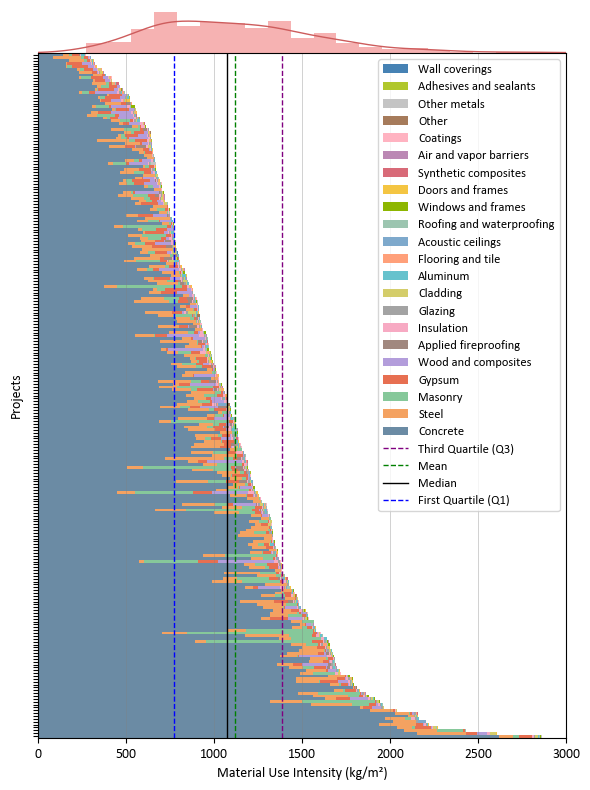

In [76]:
# Existing preparation steps
mui_data = pd.read_csv('./Output Data/mui_eci_by_mat_group_bldg_prim_use.csv')

my_colors = [
    "#6b8ba4", "#f4a261", "#86c89a", "#e76f51", "#b39ddb", "#a1887f",
    "#f7aac3", "#a3a3a3", "#d4cd6a", "#66c2cd", "#ffa07a", "#7ea9cc",
    "#9cc5b0", "#8db600", "#f4c542", "#d86a78", "#bb88b4", "#ffb3c1",
    "#a67b5b", "#c4c4c4", "#b0c72c", "#4682b4"
]

filtered_data = mui_data[mui_data['bldg_proj_type'] == 'New Construction'].copy()
filtered_data['mui'] = filtered_data['mui'].replace(0, np.nan)

aggregated_data = filtered_data.groupby(['project_index', 'mat_group'])['mui'].sum().reset_index()
pivot_data = aggregated_data.pivot(index='project_index', columns='mat_group', values='mui').fillna(0)
pivot_data['Total_mui'] = pivot_data.sum(axis=1)
pivot_data = pivot_data.sort_values(by='Total_mui', ascending=False)
plot_data = pivot_data.drop(columns='Total_mui')

sorted_mat_groups = filtered_data.groupby('mat_group')['mui'].mean().sort_values(ascending=False).index.tolist()
plot_data = plot_data.reindex(columns=sorted_mat_groups)

q1 = pivot_data['Total_mui'].quantile(0.25)
median = pivot_data['Total_mui'].median()
mean = pivot_data['Total_mui'].mean()
q3 = pivot_data['Total_mui'].quantile(0.75)

# Define the figure with GridSpec for precise alignment
fig = plt.figure(figsize=(6, 8))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[0.25, 4], hspace=0)

# Histogram and distribution line plot (top)
ax_top = fig.add_subplot(gs[0])
bins_number = 20 # number of bins.
ax_top.hist(pivot_data['Total_mui'], bins=bins_number, color='lightcoral', edgecolor='none', density=True, alpha=0.6)
kde = gaussian_kde(pivot_data['Total_mui'])
x_range = np.linspace(0, 3000, 500)
ax_top.plot(x_range, kde(x_range), color='indianred', linewidth=1)
ax_top.set_xlim(0, 3000)
ax_top.set_xticks([])
ax_top.set_yticks([])
sns.despine(ax=ax_top, left=True, bottom=True)
ax_top.margins(x=0)

# Horizontal Stacked Bar Chart (bottom)
ax_bar = fig.add_subplot(gs[1])
plot_data.plot(kind='barh', stacked=True, ax=ax_bar, color=my_colors, edgecolor='none', width=1)
ax_bar.set_xlim(0, 3000)

# Q1, Median, Mean, Q3 lines
ax_bar.axvline(q1, color='blue', linestyle='--', linewidth=1, label='First Quartile (Q1)')
ax_bar.axvline(median, color='black', linestyle='-', linewidth=1, label='Median')
ax_bar.axvline(mean, color='green', linestyle='--', linewidth=1, label='Mean')
ax_bar.axvline(q3, color='purple', linestyle='--', linewidth=1, label='Third Quartile (Q3)')

ax_bar.set_xlabel("Material Use Intensity (kg/m²)", fontsize=10)
ax_bar.set_ylabel("Projects")
ax_bar.set_yticklabels([])
ax_bar.grid(axis='x', linestyle='-', color='gray', alpha=0.5, linewidth=0.5)

handles, labels = ax_bar.get_legend_handles_labels()
ax_bar.legend(reversed(handles), reversed(labels), loc='upper right', bbox_to_anchor=(1, 1), fontsize=9, frameon=True)

# Adjust layout for better readability
plt.tight_layout()

# Define the directory and filename where you want to save the image
save_path = "./Image Exports/Fig.S1.projects-mui.png"  # Change this to your desired directory

# Save the figure with a high resolution
fig.savefig(save_path, dpi=600, bbox_inches="tight")

print(f"Figure saved at: {save_path}")

plt.show()

###### ECI

Figure saved at: ./Image Exports/Fig.S2.projects-eci.png


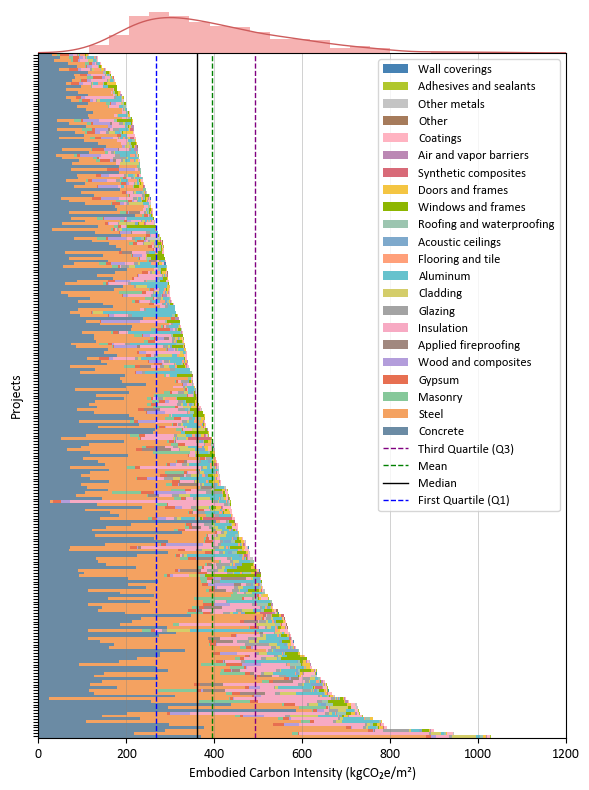

In [77]:
# Load the dataset
mui_data = pd.read_csv('./Output Data/mui_eci_by_mat_group_bldg_prim_use.csv')

# Define the colors
my_colors = [
    "#6b8ba4", "#f4a261", "#86c89a", "#e76f51", "#b39ddb", "#a1887f",
    "#f7aac3", "#a3a3a3", "#d4cd6a", "#66c2cd", "#ffa07a", "#7ea9cc",
    "#9cc5b0", "#8db600", "#f4c542", "#d86a78", "#bb88b4", "#ffb3c1",
    "#a67b5b", "#c4c4c4", "#b0c72c", "#4682b4"
]

# Filter data for New Construction projects
filtered_data = mui_data[mui_data['bldg_proj_type'] == 'New Construction'].copy()

# Replace zeros and blanks with NaN for Embodied Carbon Intensities
filtered_data['eci'] = filtered_data['eci'].replace(0, np.nan)

# Aggregate embodied carbon intensity by project_index and mat_group
aggregated_data = (
    filtered_data.groupby(['project_index', 'mat_group'])['eci']
    .sum()
    .reset_index()
)

# Pivot the data for stacked bar plotting
pivot_data = aggregated_data.pivot(index='project_index', columns='mat_group', values='eci').fillna(0)

# Calculate total embodied carbon intensity per project and sort projects in descending order
pivot_data['Total_eci'] = pivot_data.sum(axis=1)
pivot_data = pivot_data.sort_values(by='Total_eci', ascending=False)

# Drop the 'Total_eci' column before plotting
plot_data = pivot_data.drop(columns='Total_eci')

# Get sorted material groups by mean MUI
sorted_mat_groups = filtered_data.groupby('mat_group')['mui'].mean().sort_values(ascending=False).index.tolist()
plot_data = plot_data.reindex(columns=sorted_mat_groups)

# Calculate Q1, median, mean, and Q3 for Total_eci
q1 = pivot_data['Total_eci'].quantile(0.25)
median = pivot_data['Total_eci'].median()
mean = pivot_data['Total_eci'].mean()
q3 = pivot_data['Total_eci'].quantile(0.75)

# Define the figure with GridSpec for precise alignment
fig = plt.figure(figsize=(6, 8))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[0.25, 4], hspace=0)

# Histogram and distribution line plot (top)
ax_top = fig.add_subplot(gs[0])
ax_top.hist(pivot_data['Total_eci'], bins=20, color='lightcoral', edgecolor='none', density=True, alpha=0.6)
kde = gaussian_kde(pivot_data['Total_eci'])
x_range = np.linspace(0, 1200, 500) # x_range change
ax_top.plot(x_range, kde(x_range), color='indianred', linewidth=1)
ax_top.set_xlim(0, 1200) # xlim change
ax_top.set_xticks([])
ax_top.set_yticks([])
sns.despine(ax=ax_top, left=True, bottom=True)
ax_top.margins(x=0)

# Horizontal Stacked Bar Chart (bottom)
ax_bar = fig.add_subplot(gs[1])
plot_data.plot(kind='barh', stacked=True, ax=ax_bar, color=my_colors, edgecolor='none', width=1)
ax_bar.set_xlim(0, 1200) # xlim change

# Add Q1, median, mean, and Q3 lines
ax_bar.axvline(x=q1, color='blue', linestyle='--', linewidth=1, label='First Quartile (Q1)')
ax_bar.axvline(x=median, color='black', linestyle='-', linewidth=1, label='Median')
ax_bar.axvline(x=mean, color='green', linestyle='--', linewidth=1, label='Mean')
ax_bar.axvline(x=q3, color='purple', linestyle='--', linewidth=1, label='Third Quartile (Q3)')

# Add labels and title
ax_bar.set_xlabel("Embodied Carbon Intensity (kgCO₂e/m²)", fontsize=10)
ax_bar.set_ylabel("Projects")
ax_bar.set_yticklabels([])
ax_bar.grid(axis='x', linestyle='-', color='gray', alpha=0.5, linewidth=0.5)

handles, labels = ax_bar.get_legend_handles_labels()
ax_bar.legend(reversed(handles), reversed(labels), loc='upper right', bbox_to_anchor=(1, 1), fontsize=9, frameon=True)

# Adjust layout for better readability
plt.tight_layout()

# Define the directory and filename where you want to save the image
save_path = "./Image Exports/Fig.S2.projects-eci.png"  # Change this to your desired directory

# Save the figure with a high resolution
fig.savefig(save_path, dpi=600, bbox_inches="tight")

print(f"Figure saved at: {save_path}")

plt.show()

#### `mat_group` and `mat_type` contribution analysis

Combined stats for mat group and mat type mui and eci.

In [78]:
import pandas as pd

# Assuming you have merged_df loaded and available

# --- MUI Calculations ---
# Step 1: Calculate mean and median for each mat_group (MUI)
project_grouped_mat_group_mui = merged_df.groupby(['project_index', 'mat_group'])['mui'].sum().reset_index()
mat_group_stats_mui = project_grouped_mat_group_mui.groupby('mat_group')['mui'].agg(['mean', 'median']).reset_index()
mat_group_stats_mui.rename(columns={'mean': 'mat_group_mean_mui', 'median': 'mat_group_median_mui'}, inplace=True)

# Step 2: Calculate mean and median for each mat_type (MUI)
project_grouped_mat_type_mui = merged_df.groupby(['project_index', 'mat_type'])['mui'].sum().reset_index()
group_to_type_stats_mui = project_grouped_mat_type_mui.groupby('mat_type')['mui'].agg(['mean', 'median']).reset_index()
group_to_type_stats_mui.rename(columns={'mean': 'mat_type_mean_mui', 'median': 'mat_type_median_mui'}, inplace=True)

# Step 3: Identify mat_type for each mat_group (MUI)
mat_type_to_mat_group_mui = merged_df[['mat_group', 'mat_type']].drop_duplicates()

# Step 4: Merge stats with mat_group stats via the relationship table (MUI)
group_to_type_stats_mui = group_to_type_stats_mui.merge(mat_type_to_mat_group_mui, on='mat_type', how='left')
group_to_type_stats_mui = group_to_type_stats_mui.merge(mat_group_stats_mui, on='mat_group', how='left')

# Step 5: Calculate contribution percentages for mat_type (MUI)
group_to_type_stats_mui['mean_contribution_mui'] = group_to_type_stats_mui['mat_type_mean_mui'] / group_to_type_stats_mui.groupby('mat_group')['mat_type_mean_mui'].transform('sum')
group_to_type_stats_mui['median_contribution_mui'] = group_to_type_stats_mui['mat_type_median_mui'] / group_to_type_stats_mui.groupby('mat_group')['mat_type_median_mui'].transform('sum')

# Step 6: Normalize mat_type contributions based on mat_group stats (MUI)
group_to_type_stats_mui['normalized_mean_mui'] = group_to_type_stats_mui['mean_contribution_mui'] * group_to_type_stats_mui['mat_group_mean_mui']
group_to_type_stats_mui['normalized_median_mui'] = group_to_type_stats_mui['median_contribution_mui'] * group_to_type_stats_mui['mat_group_median_mui']

# Step 7: Prepare the output dataframe (MUI)
group_to_type_stats_df_mui = group_to_type_stats_mui[['mat_group', 'mat_type', 'normalized_mean_mui', 'normalized_median_mui']]

# --- ECI Calculations ---
# Step 1: Calculate mean and median for each mat_group (ECI)
project_grouped_mat_group_eci = merged_df.groupby(['project_index', 'mat_group'])['eci'].sum().reset_index()
mat_group_stats_eci = project_grouped_mat_group_eci.groupby('mat_group')['eci'].agg(['mean', 'median']).reset_index()
mat_group_stats_eci.rename(columns={'mean': 'mat_group_mean_eci', 'median': 'mat_group_median_eci'}, inplace=True)

# Step 2: Calculate mean and median for each mat_type (ECI)
project_grouped_mat_type_eci = merged_df.groupby(['project_index', 'mat_type'])['eci'].sum().reset_index()
group_to_type_stats_eci = project_grouped_mat_type_eci.groupby('mat_type')['eci'].agg(['mean', 'median']).reset_index()
group_to_type_stats_eci.rename(columns={'mean': 'mat_type_mean_eci', 'median': 'mat_type_median_eci'}, inplace=True)

# Step 3: Identify mat_type for each mat_group (ECI)
mat_type_to_mat_group_eci = merged_df[['mat_group', 'mat_type']].drop_duplicates()

# Step 4: Merge stats with mat_group stats via the relationship table (ECI)
group_to_type_stats_eci = group_to_type_stats_eci.merge(mat_type_to_mat_group_eci, on='mat_type', how='left')
group_to_type_stats_eci = group_to_type_stats_eci.merge(mat_group_stats_eci, on='mat_group', how='left')

# Step 5: Calculate contribution percentages for mat_type (ECI)
group_to_type_stats_eci['mean_contribution_eci'] = group_to_type_stats_eci['mat_type_mean_eci'] / group_to_type_stats_eci.groupby('mat_group')['mat_type_mean_eci'].transform('sum')
group_to_type_stats_eci['median_contribution_eci'] = group_to_type_stats_eci['mat_type_median_eci'] / group_to_type_stats_eci.groupby('mat_group')['mat_type_median_eci'].transform('sum')

# Step 6: Normalize mat_type contributions based on mat_group stats (ECI)
group_to_type_stats_eci['normalized_mean_eci'] = group_to_type_stats_eci['mean_contribution_eci'] * group_to_type_stats_eci['mat_group_mean_eci']
group_to_type_stats_eci['normalized_median_eci'] = group_to_type_stats_eci['median_contribution_eci'] * group_to_type_stats_eci['mat_group_median_eci']

# Step 7: Prepare the output dataframe (ECI)
group_to_type_stats_df_eci = group_to_type_stats_eci[['mat_group', 'mat_type', 'normalized_mean_eci', 'normalized_median_eci']]

# --- Merge MUI and ECI DataFrames ---
group_to_type_stats_df_mui_eci = pd.merge(group_to_type_stats_df_mui, group_to_type_stats_df_eci, on=['mat_group', 'mat_type'], how='outer')

# Sort the results for clarity
group_to_type_stats_df_mui_eci = group_to_type_stats_df_mui_eci.sort_values(by=['mat_group', 'mat_type'])

# Save to Excel (optional)
group_to_type_stats_df_mui_eci.to_excel('./Output Data/mat_group_to_type_stats_df_mui_eci.xlsx', index=False)

# Display the resulting dataframe
group_to_type_stats_df_mui_eci

,mat_group,mat_type,normalized_mean_mui,normalized_median_mui,normalized_mean_eci,normalized_median_eci
0,Acoustic ceilings,Acoustic ceiling tile aluminum,0.178647,0.047733,0.939156,0.271724
1,Acoustic ceilings,Acoustic ceiling tile fiber,0.679750,0.470077,0.885480,0.551537
2,Acoustic ceilings,Acoustic ceiling tile steel,0.228758,0.029067,0.612354,0.071633
3,Acoustic ceilings,Acoustic ceilings - other,0.631034,0.464614,0.732969,0.626358
4,Acoustic ceilings,Suspension assembly,0.320780,0.117895,0.279058,0.225584
...,...,...,...,...,...,...
112,Wood and composites,Parallel strand lumber PSL,0.330081,0.030555,0.112781,0.012383
113,Wood and composites,Softwood framing,3.209343,0.157883,0.488058,0.029052
114,Wood and composites,Softwood plywood,1.448898,0.094156,0.424631,0.027226
115,Wood and composites,Wood I joists,1.018862,0.285095,0.429846,0.143642


In [79]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# Assuming group_to_type_stats_df_mui_eci is your merged DataFrame

# --- MUI Chart ---
# Sort the group_to_type_stats_df_mui_eci by mat_group for consistent ordering
group_to_type_stats_df_mui = group_to_type_stats_df_mui_eci.sort_values(by=['mat_group', 'normalized_mean_mui'], ascending=[True, False])

# Pivot the data to create stacked structures for means and medians
stacked_data_mean_mui = group_to_type_stats_df_mui.pivot(index='mat_group', columns='mat_type', values='normalized_mean_mui').fillna(0)
stacked_data_median_mui = group_to_type_stats_df_mui.pivot(index='mat_group', columns='mat_type', values='normalized_median_mui').fillna(0)

# Calculate total means and medians for each mat_group
stacked_data_mean_mui['total_mean'] = stacked_data_mean_mui.sum(axis=1)
stacked_data_median_mui['total_median'] = stacked_data_median_mui.sum(axis=1)

# Function to create a horizontal stacked bar chart
def create_chart(stacked_data, total_col, title, x_title):
    fig = go.Figure()

    # Add traces for each mat_type
    for mat_type_category in stacked_data.columns[:-1]:  # Exclude the total column
        fig.add_trace(go.Bar(
            name=mat_type_category,  # Name of the wedge category
            x=stacked_data[mat_type_category],  # Normalized values on x-axis
            y=stacked_data.index,  # mat_group categories on y-axis
            orientation='h',  # Horizontal orientation
            hovertemplate=(
                "<b>Material Group:</b> %{y}<br>"  # Show mat_group
                "<b>Wedge Category:</b> " + mat_type_category + "<br>"  # Show mat_type
                "<b>Contribution:</b> %{x:.2f} <extra></extra>"  # Show contribution
            ),
            marker=dict(opacity=0.8)
        ))

    # Add annotations for totals
    for i, mat_group in enumerate(stacked_data.index):
        total_value = stacked_data.loc[mat_group, total_col]
        fig.add_annotation(
            x=np.log10(total_value) if total_value > 0 else 0,  # Adjust position for log scale
            y=mat_group,
            text=f"{total_value:.2f}",  # Show total value
            showarrow=False,
            font=dict(size=10, color='black'),
            xanchor='left',  # Anchor the text to the left of the position
            align='center'
        )

    # Update layout
    fig.update_layout(
        title=title,
        xaxis=dict(
            title=x_title,
            type='log',  # Set to logarithmic scale
            showgrid=True,
            gridcolor='lightgrey'
        ),
        yaxis=dict(
            title='Material Group',
            showgrid=False,  # Remove horizontal gridlines
            categoryorder='total ascending'
        ),
        barmode='stack',  # Stack mode for bars
        height=1000,
        width=1400,
        showlegend=True,
        plot_bgcolor='rgba(0,0,0,0)',
        legend_traceorder='normal'
    )
    return fig

# Create MUI chart
mean_chart_mui = create_chart(stacked_data_mean_mui, 'total_mean', "Stacked Bar Chart of Mean Material Use Intensities per Material Group", "Material Use Intensity (kg/m²)")
mean_chart_mui.show()

# --- ECI Chart ---
# Sort the group_to_type_stats_df_mui_eci by mat_group for consistent ordering
group_to_type_stats_df_eci = group_to_type_stats_df_mui_eci.sort_values(by=['mat_group', 'normalized_mean_eci'], ascending=[True, False])

# Pivot the data to create stacked structures for means and medians
stacked_data_mean_eci = group_to_type_stats_df_eci.pivot(index='mat_group', columns='mat_type', values='normalized_mean_eci').fillna(0)
stacked_data_median_eci = group_to_type_stats_df_eci.pivot(index='mat_group', columns='mat_type', values='normalized_median_eci').fillna(0)

# Calculate total means and medians for each mat_group
stacked_data_mean_eci['total_mean'] = stacked_data_mean_eci.sum(axis=1)
stacked_data_median_eci['total_median'] = stacked_data_median_eci.sum(axis=1)

# Create ECI chart
mean_chart_eci = create_chart(stacked_data_mean_eci, 'total_mean', "Stacked Bar Chart of Mean Embodied Carbon Intensities per Material Group", "Embodied Carbon Intensity (kgCO₂e/m²)")
mean_chart_eci.show()